In [50]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

#path = 'C:/Users/julia/PycharmProjects/gnn-for-ppi/final_results/KIRC' #old
#path = 'C:/Users/schirmacher3/PycharmProjects/gnn-for-ppi/final_results/BRCA'
path = 'C:/Users/julia/PycharmProjects/gnn-for-ppi/final_results/BRCA'

# OUTER EXTENDED
#full
MLP_outer_ext = pd.read_csv(path+'/MLP/results_outer_extended.csv')
GCN_outer_ext = pd.read_csv(path+'/GCN/results_outer_extended.csv')
GAT_outer_ext = pd.read_csv(path+'/GAT/results_outer_extended.csv')
ChebNet_outer_ext = pd.read_csv(path+'/ChebNet/results_outer_extended.csv')
GCN2MLP_outer_ext = pd.read_csv(path+'/GCN2MLP/results_outer_extended.csv')
GAT2MLP_outer_ext = pd.read_csv(path+'/GAT2MLP/results_outer_extended.csv')
ChebNet2MLP_outer_ext = pd.read_csv(path+'/ChebNet2MLP/results_outer_extended.csv')

#methyl
mMLP_outer_ext = pd.read_csv(path+'/mMLP/results_outer_extended.csv')
mGCN_outer_ext = pd.read_csv(path+'/mGCN/results_outer_extended.csv')
mGAT_outer_ext = pd.read_csv(path+'/mGAT/results_outer_extended.csv')
mChebNet_outer_ext = pd.read_csv(path+'/mChebNet/results_outer_extended.csv')
mGCN2MLP_outer_ext = pd.read_csv(path+'/mGCN2MLP/results_outer_extended.csv')
mGAT2MLP_outer_ext = pd.read_csv(path+'/mGAT2MLP/results_outer_extended.csv')
mChebNet2MLP_outer_ext = pd.read_csv(path+'/mChebNet2MLP/results_outer_extended.csv')

#expr
xMLP_outer_ext = pd.read_csv(path+'/xMLP/results_outer_extended.csv')
xGCN_outer_ext = pd.read_csv(path+'/xGCN/results_outer_extended.csv')
xGAT_outer_ext = pd.read_csv(path+'/xGAT/results_outer_extended.csv')
xChebNet_outer_ext = pd.read_csv(path+'/xChebNet/results_outer_extended.csv')
xGCN2MLP_outer_ext = pd.read_csv(path+'/xGCN2MLP/results_outer_extended.csv')
xGAT2MLP_outer_ext = pd.read_csv(path+'/xGAT2MLP/results_outer_extended.csv')
xChebNet2MLP_outer_ext = pd.read_csv(path+'/xChebNet2MLP/results_outer_extended.csv')

# INNER EXTENDED
#full
MLP_inner_ext = pd.read_csv(path+'/MLP/results_inner_extended.csv')
GCN_inner_ext = pd.read_csv(path+'/GCN/results_inner_extended.csv')
GAT_inner_ext = pd.read_csv(path+'/GAT/results_inner_extended.csv')
ChebNet_inner_ext = pd.read_csv(path+'/ChebNet/results_inner_extended.csv')
GCN2MLP_inner_ext = pd.read_csv(path+'/GCN2MLP/results_inner_extended.csv')
GAT2MLP_inner_ext = pd.read_csv(path+'/GAT2MLP/results_inner_extended.csv')
ChebNet2MLP_inner_ext = pd.read_csv(path+'/ChebNet2MLP/results_inner_extended.csv')

#OUTER AVERAGE
#full
MLP_outer_av = pd.read_csv(path+'/MLP/results_outer_average_over_folds.csv')
GCN_outer_av = pd.read_csv(path+'/GCN/results_outer_average_over_folds.csv')
GAT_outer_av = pd.read_csv(path+'/GAT/results_outer_average_over_folds.csv')
ChebNet_outer_av = pd.read_csv(path+'/ChebNet/results_outer_average_over_folds.csv')
GCN2MLP_outer_av = pd.read_csv(path+'/GCN2MLP/results_outer_average_over_folds.csv')
GAT2MLP_outer_av = pd.read_csv(path+'/GAT2MLP/results_outer_average_over_folds.csv')
ChebNet2MLP_outer_av = pd.read_csv(path+'/ChebNet2MLP/results_outer_average_over_folds.csv')


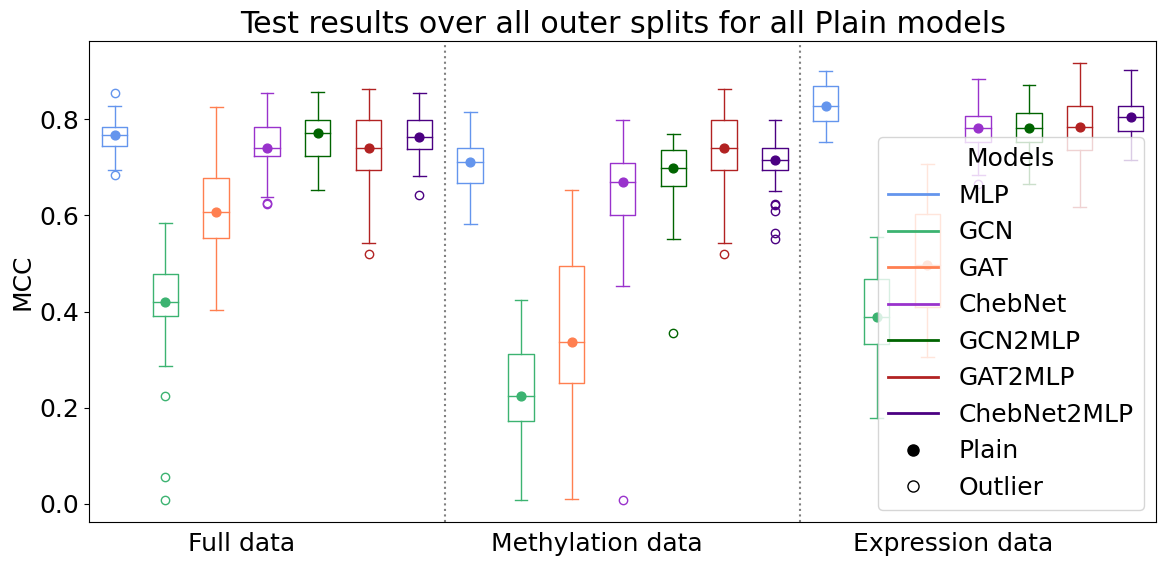

In [ ]:
# All models, incl. new models (GCN/GAT2MLP) - MCC box plots
mpl.rcParams.update({'font.size': 18})

colors = ['cornflowerblue', 'mediumseagreen', 'coral', 'darkorchid', 'darkgreen', 'firebrick', 'indigo' ]
symbols = ['o'] 

data = [    MLP_outer_ext['test_mcc'],
            GCN_outer_ext['test_mcc'],
            GAT_outer_ext['test_mcc'],
            ChebNet_outer_ext['test_mcc'],
            GCN2MLP_outer_ext['test_mcc'],
            GAT2MLP_outer_ext['test_mcc'],
            ChebNet2MLP_outer_ext['test_mcc'],
            mMLP_outer_ext['test_mcc'],
            mGCN_outer_ext['test_mcc'],
            mGAT_outer_ext['test_mcc'],
            mChebNet_outer_ext['test_mcc'],
            mGCN2MLP_outer_ext['test_mcc'],
            mGAT2MLP_outer_ext['test_mcc'],
            mChebNet2MLP_outer_ext['test_mcc'],
            xMLP_outer_ext['test_mcc'],
            xGCN_outer_ext['test_mcc'],
            xGAT_outer_ext['test_mcc'],
            xChebNet_outer_ext['test_mcc'],
            xGCN2MLP_outer_ext['test_mcc'],
            xGAT2MLP_outer_ext['test_mcc'],
            xChebNet2MLP_outer_ext['test_mcc']
            ]

fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(data, showcaps=True)

for i in range(len(bp['boxes'])):
    group_color = colors[(i // 1)%7] 

    bp['boxes'][i].set(color=group_color, linewidth=1)
    bp['caps'][2 * i].set(color=group_color, linewidth=1)    
    bp['caps'][2 * i + 1].set(color=group_color, linewidth=1)  
    bp['whiskers'][2 * i].set(color=group_color, linewidth=1)     
    bp['whiskers'][2 * i + 1].set(color=group_color, linewidth=1) 

    median = np.median(data[i])
    ax.scatter(i + 1, median, color=group_color, s=40, marker=symbols[0], zorder=3)
    bp['medians'][i].set(color=group_color, linewidth=1)
    bp['fliers'][i].set(markeredgecolor=group_color)

plt.axvline(x=7.5, color='grey', linestyle=':')
plt.axvline(x=14.5, color='grey', linestyle=':')

groups_colors = ['MLP', 'GCN', 'GAT', 'ChebNet', 'GCN2MLP', 'GAT2MLP', 'ChebNet2MLP']
groups_shapes = ['Plain']

legend_handles = [
                    Line2D([0], [0], color=color, lw=2, label=name)
                    for color, name in zip(colors, groups_colors)
                ]+[
                    Line2D([0], [0], color='black', marker=symbol, markersize=8, linestyle='None', label=name)
                    for symbol, name in zip(symbols, groups_shapes)
                ]+ [Line2D([0], [0], color='black', marker='o',markerfacecolor='none',
                        markeredgecolor='black', markersize=8, linestyle='None', label='Outlier')]

ax.legend(handles=legend_handles, title='Models')
ax.set_xticks([])
ax.set_ylabel('MCC')

ax.set_xticks([3.5, 10.5, 17.5],['Full data', 'Methylation data', 'Expression data'] )
ax.xaxis.set_ticks_position('none') 
ax.set_title('Test results over all outer splits for all Plain models')

plt.tight_layout()
'''
plt.savefig(path+'/final_box_metric_extended.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/final_box_metric_extended.pdf', bbox_inches='tight')
'''
plt.show()


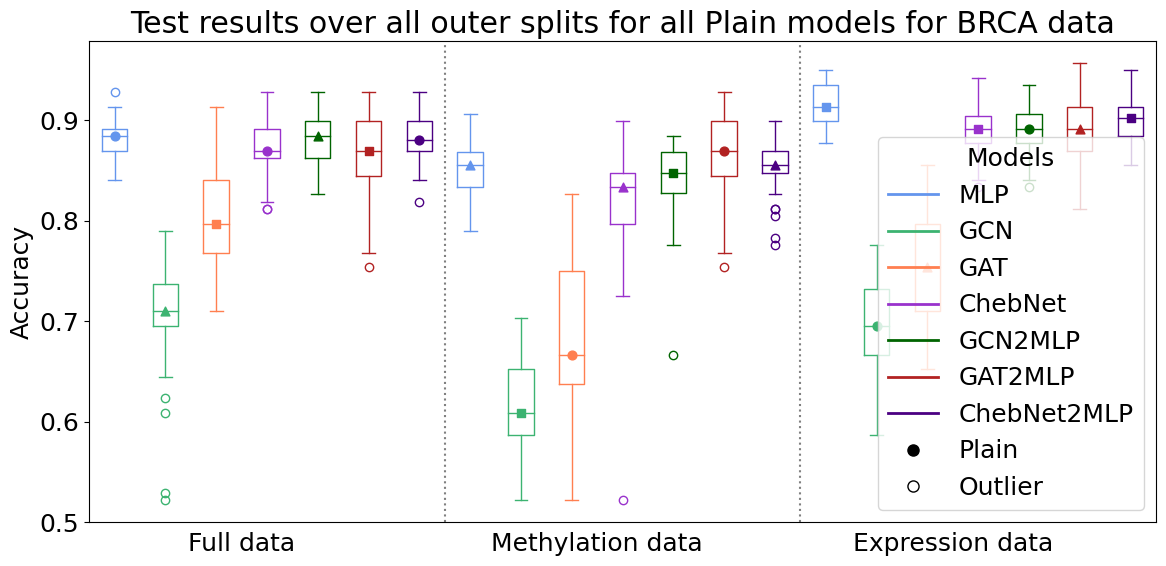

In [ ]:
# All models, incl. new models (GCN/GAT2MLP) - accuracy box plots

colors = ['cornflowerblue', 'mediumseagreen', 'coral', 'darkorchid', 'darkgreen', 'firebrick', 'indigo' ]
symbols = ['o', '^', 's'] 

data = [    MLP_outer_ext['test_accuracy'],
            GCN_outer_ext['test_accuracy'],
            GAT_outer_ext['test_accuracy'],
            ChebNet_outer_ext['test_accuracy'],
            GCN2MLP_outer_ext['test_accuracy'],
            GAT2MLP_outer_ext['test_accuracy'],
            ChebNet2MLP_outer_ext['test_accuracy'],
            mMLP_outer_ext['test_accuracy'],
            mGCN_outer_ext['test_accuracy'],
            mGAT_outer_ext['test_accuracy'],
            mChebNet_outer_ext['test_accuracy'],
            mGCN2MLP_outer_ext['test_accuracy'],
            mGAT2MLP_outer_ext['test_accuracy'],
            mChebNet2MLP_outer_ext['test_accuracy'],
            xMLP_outer_ext['test_accuracy'],
            xGCN_outer_ext['test_accuracy'],
            xGAT_outer_ext['test_accuracy'],
            xChebNet_outer_ext['test_accuracy'],
            xGCN2MLP_outer_ext['test_accuracy'],
            xGAT2MLP_outer_ext['test_accuracy'],
            xChebNet2MLP_outer_ext['test_accuracy']
            ]

fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(data, showcaps=True)

for i in range(len(bp['boxes'])):
    group_color = colors[(i // 1)%7] 

    bp['boxes'][i].set(color=group_color, linewidth=1)
    bp['caps'][2 * i].set(color=group_color, linewidth=1)    
    bp['caps'][2 * i + 1].set(color=group_color, linewidth=1)  
    bp['whiskers'][2 * i].set(color=group_color, linewidth=1)     
    bp['whiskers'][2 * i + 1].set(color=group_color, linewidth=1) 

    median = np.median(data[i])
    ax.scatter(i + 1, median, color=group_color, s=40, marker=symbols[i % 3], zorder=3)
    bp['medians'][i].set(color=group_color, linewidth=1)
    bp['fliers'][i].set(markeredgecolor=group_color)

plt.axvline(x=7.5, color='grey', linestyle=':')
plt.axvline(x=14.5, color='grey', linestyle=':')

groups_colors = ['MLP', 'GCN', 'GAT', 'ChebNet', 'GCN2MLP', 'GAT2MLP', 'ChebNet2MLP']
groups_shapes = ['Plain']

legend_handles = [
                    Line2D([0], [0], color=color, lw=2, label=name)
                    for color, name in zip(colors, groups_colors)
                ]+[
                    Line2D([0], [0], color='black', marker=symbol, markersize=8, linestyle='None', label=name)
                    for symbol, name in zip(symbols, groups_shapes)
                ]+ [Line2D([0], [0], color='black', marker='o',markerfacecolor='none',
                        markeredgecolor='black', markersize=8, linestyle='None', label='Outlier')]

ax.legend(handles=legend_handles, title='Models')
ax.set_xticks([])
ax.set_ylabel('Accuracy')

ax.set_xticks([3.5, 10.5, 17.5],['Full data', 'Methylation data', 'Expression data'] )
ax.xaxis.set_ticks_position('none') 
ax.set_title('Test results over all outer splits for all Plain models for BRCA data')

plt.tight_layout()
'''
plt.savefig(path+'/final_box_accuracy_extended.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/final_box_accuracy_extended.pdf', bbox_inches='tight')
'''
plt.show()


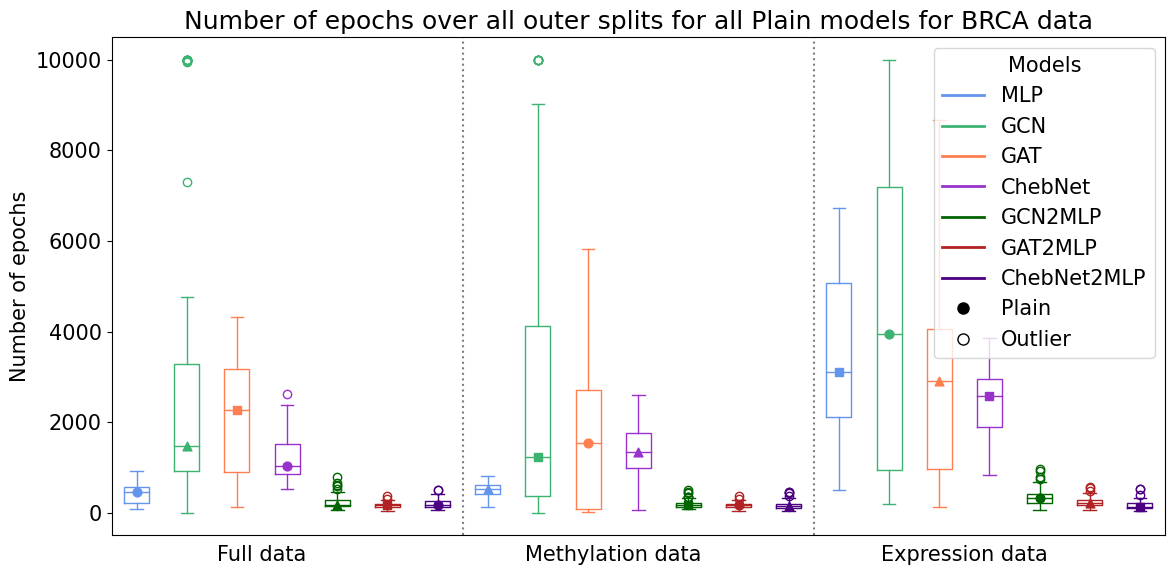

In [ ]:
# All models, incl. new models (GCN/GAT2MLP) - number of epochs box plots
mpl.rcParams.update({'font.size': 15})
colors = ['cornflowerblue', 'mediumseagreen', 'coral', 'darkorchid', 'darkgreen', 'firebrick', 'indigo' ]
symbols = ['o', '^', 's'] 

data = [    MLP_outer_ext['number_epochs'],
            GCN_outer_ext['number_epochs'],
            GAT_outer_ext['number_epochs'],
            ChebNet_outer_ext['number_epochs'],
            GCN2MLP_outer_ext['number_epochs'],
            GAT2MLP_outer_ext['number_epochs'],
            ChebNet2MLP_outer_ext['number_epochs'],
            mMLP_outer_ext['number_epochs'],
            mGCN_outer_ext['number_epochs'],
            mGAT_outer_ext['number_epochs'],
            mChebNet_outer_ext['number_epochs'],
            mGCN2MLP_outer_ext['number_epochs'],
            mGAT2MLP_outer_ext['number_epochs'],
            mChebNet2MLP_outer_ext['number_epochs'],
            xMLP_outer_ext['number_epochs'],
            xGCN_outer_ext['number_epochs'],
            xGAT_outer_ext['number_epochs'],
            xChebNet_outer_ext['number_epochs'],
            xGCN2MLP_outer_ext['number_epochs'],
            xGAT2MLP_outer_ext['number_epochs'],
            xChebNet2MLP_outer_ext['number_epochs']
            ]

fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(data, showcaps=True)

for i in range(len(bp['boxes'])):
    group_color = colors[(i // 1)%7] 

    bp['boxes'][i].set(color=group_color, linewidth=1)
    bp['caps'][2 * i].set(color=group_color, linewidth=1)    
    bp['caps'][2 * i + 1].set(color=group_color, linewidth=1)  
    bp['whiskers'][2 * i].set(color=group_color, linewidth=1)     
    bp['whiskers'][2 * i + 1].set(color=group_color, linewidth=1) 

    median = np.median(data[i])
    ax.scatter(i + 1, median, color=group_color, s=40, marker=symbols[i % 3], zorder=3)
    bp['medians'][i].set(color=group_color, linewidth=1)
    bp['fliers'][i].set(markeredgecolor=group_color)

plt.axvline(x=7.5, color='grey', linestyle=':')
plt.axvline(x=14.5, color='grey', linestyle=':')

groups_colors = ['MLP', 'GCN', 'GAT', 'ChebNet', 'GCN2MLP', 'GAT2MLP', 'ChebNet2MLP']
groups_shapes = ['Plain']

legend_handles = [
                    Line2D([0], [0], color=color, lw=2, label=name)
                    for color, name in zip(colors, groups_colors)
                ]+[
                    Line2D([0], [0], color='black', marker=symbol, markersize=8, linestyle='None', label=name)
                    for symbol, name in zip(symbols, groups_shapes)
                ]+ [Line2D([0], [0], color='black', marker='o',markerfacecolor='none',
                        markeredgecolor='black', markersize=8, linestyle='None', label='Outlier')]

ax.legend(handles=legend_handles, title='Models')
ax.set_xticks([])
ax.set_ylabel('Number of epochs')

ax.set_xticks([3.5, 10.5, 17.5],['Full data', 'Methylation data', 'Expression data'] )
ax.xaxis.set_ticks_position('none') 
ax.set_title('Number of epochs over all outer splits for all Plain models for BRCA data')

plt.tight_layout()
'''
plt.savefig(path+'/final_box_epochs.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/final_box_epochs.pdf', bbox_inches='tight')
'''
plt.show()
mpl.rcParams.update({'font.size': 18})


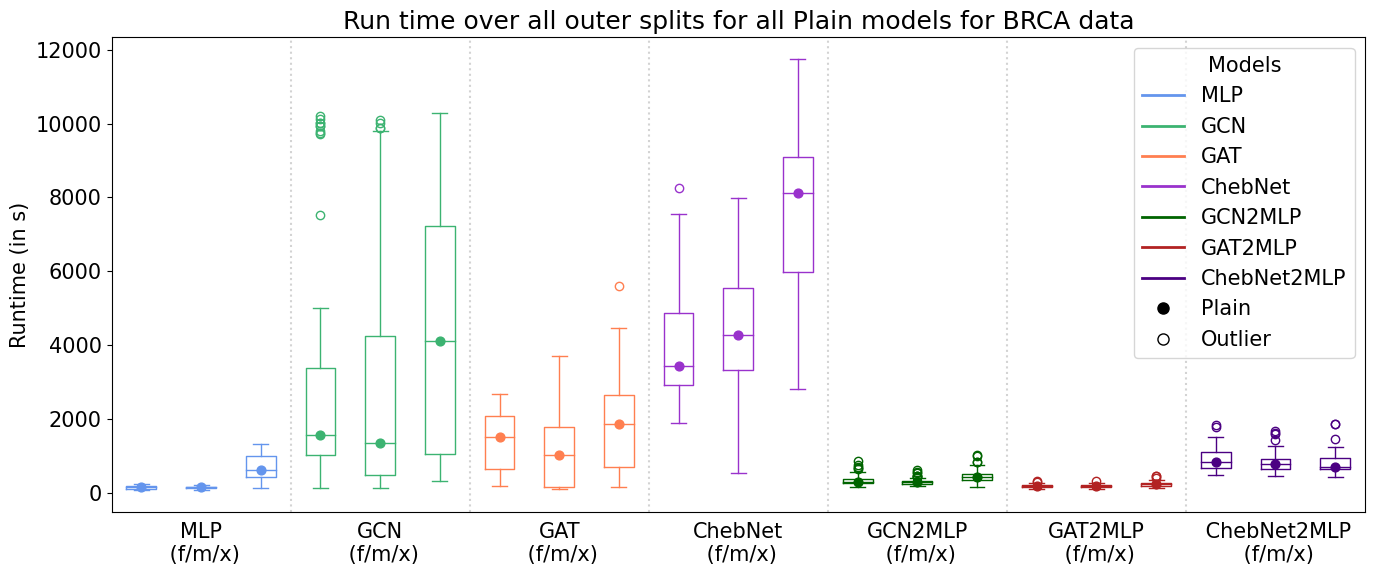

In [ ]:
### ADAPT Y AXIS 
# Time total ALL MODELS INCL RERUN (but wo Res/Dense)
mpl.rcParams.update({'font.size': 14})

colors = ['cornflowerblue', 'mediumseagreen', 'coral', 'darkorchid', 'darkgreen', 'firebrick', 'indigo' ]
symbols = ['o', '^', 's'] 

data = [    MLP_outer_ext['time_total_s'],
            mMLP_outer_ext['time_total_s'],
            xMLP_outer_ext['time_total_s'],
            GCN_outer_ext['time_total_s'],
            mGCN_outer_ext['time_total_s'],
            xGCN_outer_ext['time_total_s'],
            GAT_outer_ext['time_total_s'],
            mGAT_outer_ext['time_total_s'],
            xGAT_outer_ext['time_total_s'],
            ChebNet_outer_ext['time_total_s'],
            mChebNet_outer_ext['time_total_s'],
            xChebNet_outer_ext['time_total_s'],
            GCN2MLP_outer_ext['time_total_s'],
            mGCN2MLP_outer_ext['time_total_s'],
            xGCN2MLP_outer_ext['time_total_s'],
            GAT2MLP_outer_ext['time_total_s'],
            mGAT2MLP_outer_ext['time_total_s'],
            xGAT2MLP_outer_ext['time_total_s'],
            ChebNet2MLP_outer_ext['time_total_s'],
            mChebNet2MLP_outer_ext['time_total_s'],
            xChebNet2MLP_outer_ext['time_total_s'],
            ]

group_colors = [colors[0],colors[0],colors[0],
                colors[1],colors[1],colors[1],
                colors[2],colors[2],colors[2],
                colors[3],colors[3],colors[3],
                colors[4],colors[4],colors[4],
                colors[5],colors[5],colors[5],
                colors[6],colors[6],colors[6],
                colors[0],
                colors[1], colors[2], colors[3], colors[4], colors[5], colors[6],
                colors[1], colors[2], colors[3], colors[4], colors[5], colors[6],
                colors[1], colors[2], colors[3], colors[4], colors[5], colors[6],
                colors[1], colors[2], colors[3], colors[4], colors[5], colors[6]]

group_symbols = [symbols[0],symbols[0],symbols[0],
                 symbols[0],symbols[0],symbols[0],
                 symbols[0],symbols[0],symbols[0],
                 symbols[0],symbols[0],symbols[0],
                 symbols[0],symbols[0],symbols[0],
                 symbols[0],symbols[0],symbols[0],
                 symbols[0],symbols[0],symbols[0],
                 symbols[0],
                 symbols[0],symbols[0],symbols[0],symbols[0],symbols[0],symbols[0],
                 symbols[0],symbols[0],symbols[0],symbols[0],symbols[0],symbols[0],
                 symbols[0],symbols[0],symbols[0],symbols[0],symbols[0],symbols[0],
                 symbols[0],symbols[0],symbols[0],symbols[0],symbols[0],symbols[0]]

fig, ax = plt.subplots(figsize=(14, 6)) # for large version: (14,12)
bp = ax.boxplot(data, showcaps=True)

for i in range(len(bp['boxes'])):
    group_color = group_colors[i]
    symbol = group_symbols[i]

    bp['boxes'][i].set(color=group_color, linewidth=1)
    bp['caps'][2 * i].set(color=group_color, linewidth=1)    
    bp['caps'][2 * i + 1].set(color=group_color, linewidth=1)  
    bp['whiskers'][2 * i].set(color=group_color, linewidth=1)     
    bp['whiskers'][2 * i + 1].set(color=group_color,  linewidth=1) 

    median = np.median(data[i])
    ax.scatter(i + 1, median, color=group_color,  marker=symbol, s=40, zorder=3)
    bp['medians'][i].set(color=group_color, linewidth=1)
    bp['fliers'][i].set(markeredgecolor=group_color)

#plt.axvline(x=1.5, color='grey', linestyle=':')
plt.axvline(x=3.5, color='lightgrey', linestyle=':')
plt.axvline(x=6.5, color='lightgrey', linestyle=':')
plt.axvline(x=9.5, color='lightgrey', linestyle=':')
plt.axvline(x=12.5, color='lightgrey', linestyle=':')
plt.axvline(x=15.5, color='lightgrey', linestyle=':')
plt.axvline(x=18.5, color='lightgrey', linestyle=':')


groups_colors = ['MLP', 'GCN', 'GAT', 'ChebNet', 'GCN2MLP', 'GAT2MLP', 'ChebNet2MLP']
groups_shapes = ['Plain']

legend_handles = [
                    Line2D([0], [0], color=color, lw=2, label=name)
                    for color, name in zip(colors, groups_colors)
                ]+[
                    Line2D([0], [0], color='black', marker=symbol, markersize=8, linestyle='None', label=name)
                    for symbol, name in zip(symbols, groups_shapes)
                ]+ [Line2D([0], [0], color='black', marker='o',markerfacecolor='none',
                        markeredgecolor='black', markersize=8, linestyle='None', label='Outlier')]


ax.legend(handles=legend_handles, title='Models')
ax.set_xticks([])
ax.set_ylabel('Runtime (in s)')

ax.set_xticks([2,5, 8, 11, 14, 17, 20],['MLP\n (f/m/x)', 'GCN\n (f/m/x)','GAT\n (f/m/x)','ChebNet\n (f/m/x)','GCN2MLP\n (f/m/x)', 'GAT2MLP\n (f/m/x)', ' ChebNet2MLP\n (f/m/x)'] )
ax.xaxis.set_ticks_position('none') 
ax.set_title('Run time over all outer splits for all Plain models for BRCA data')

#ax.set_ylim(-100, 3000) #better overview

plt.tight_layout()
'''
plt.savefig(path+'/final_box_runtime_all_plain.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/final_box_runtime_all_plain.pdf', bbox_inches='tight')
'''
plt.show()

C:\Users\julia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\categorical.py:3544: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\julia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\categorical.py:3544: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\julia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\categorical.py:3544: UserWarning: 40.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\julia\AppData\Local\Packages\Py

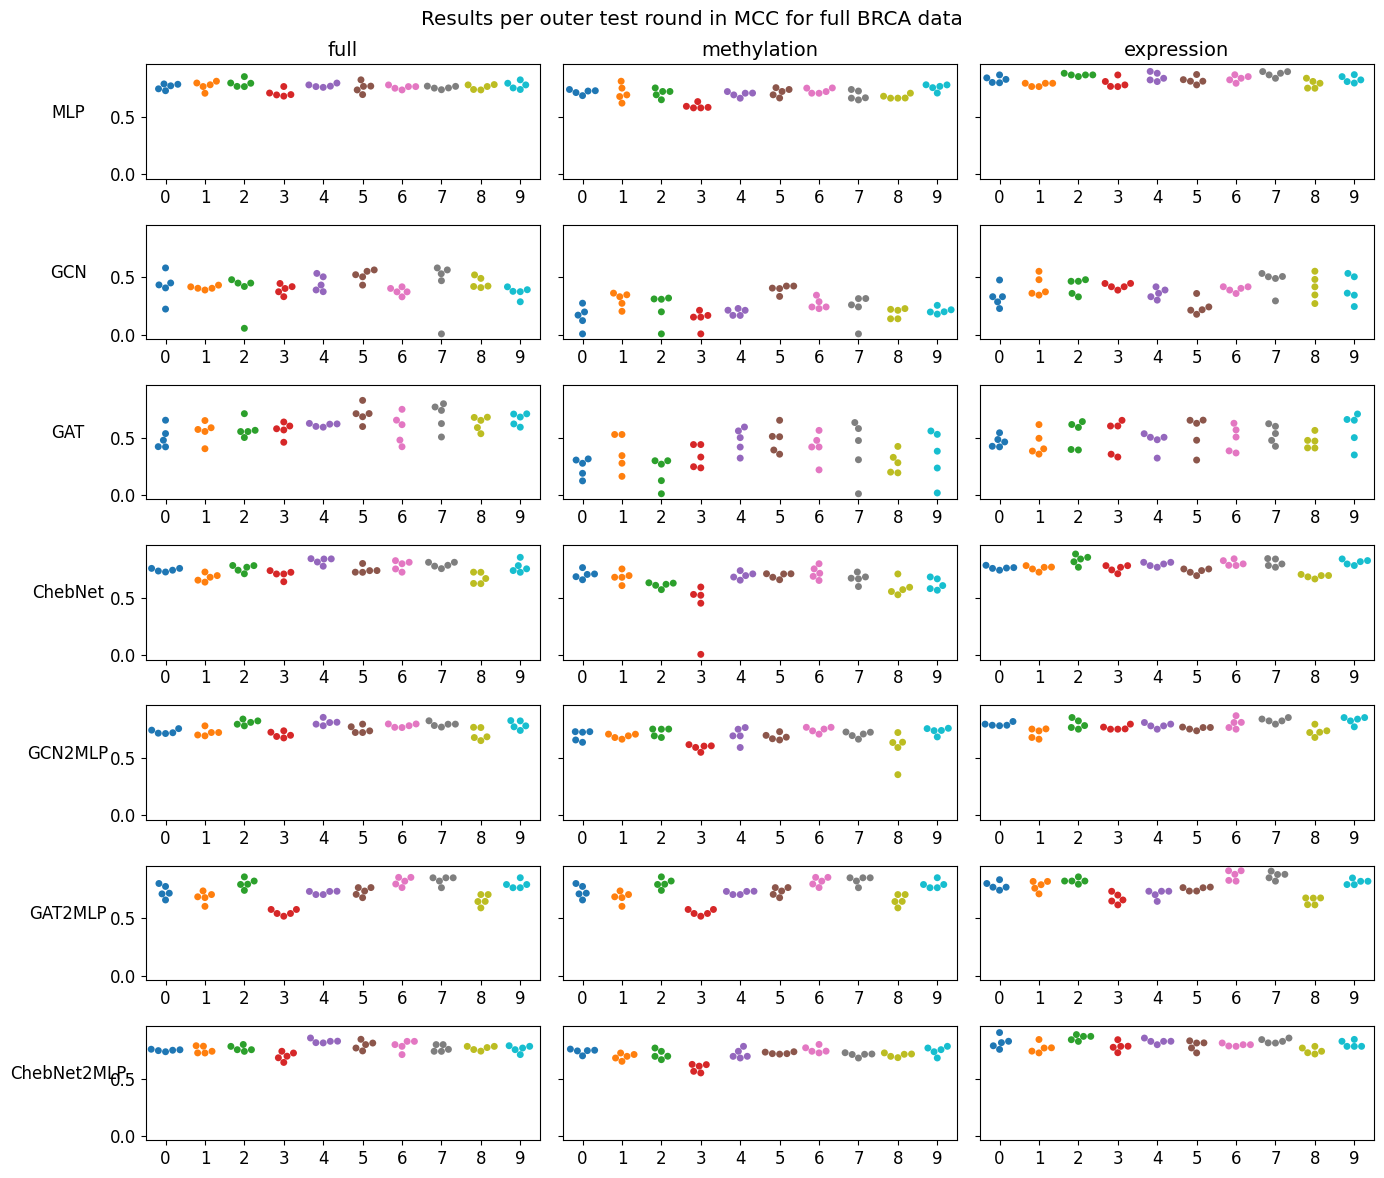

In [31]:
#SWARMPLOTS
#FULL DATA
mpl.rcParams.update({'font.size': 12})

fig, ax = plt.subplots(ncols=3, nrows=7, figsize=(14,12), sharey=True)

MLP = pd.DataFrame()
mMLP = pd.DataFrame()
xMLP = pd.DataFrame()
GCN = pd.DataFrame()
mGCN = pd.DataFrame()
xGCN = pd.DataFrame()
GAT = pd.DataFrame()
mGAT = pd.DataFrame()
xGAT = pd.DataFrame()
ChebNet = pd.DataFrame()
mChebNet = pd.DataFrame()
xChebNet = pd.DataFrame()
GCN2MLP = pd.DataFrame()
mGCN2MLP = pd.DataFrame()
xGCN2MLP = pd.DataFrame()
GAT2MLP = pd.DataFrame()
mGAT2MLP = pd.DataFrame()
xGAT2MLP = pd.DataFrame()
ChebNet2MLP = pd.DataFrame()
mChebNet2MLP = pd.DataFrame()
xChebNet2MLP = pd.DataFrame()

for i in range(10):
   MLP[str(i)] = MLP_outer_ext['test_mcc'][MLP_outer_ext['config/train_loop_config/dataset_test_round']==i].reset_index(drop=True)
   mMLP[str(i)] = mMLP_outer_ext['test_mcc'][mMLP_outer_ext['config/train_loop_config/dataset_test_round']==i].reset_index(drop=True)
   xMLP[str(i)] = xMLP_outer_ext['test_mcc'][xMLP_outer_ext['config/train_loop_config/dataset_test_round']==i].reset_index(drop=True)

   GCN[str(i)] = GCN_outer_ext['test_mcc'][GCN_outer_ext['config/train_loop_config/dataset_test_round']==i].reset_index(drop=True)
   mGCN[str(i)] = mGCN_outer_ext['test_mcc'][mGCN_outer_ext['config/train_loop_config/dataset_test_round']==i].reset_index(drop=True)
   xGCN[str(i)] = xGCN_outer_ext['test_mcc'][xGCN_outer_ext['config/train_loop_config/dataset_test_round']==i].reset_index(drop=True)

   GAT[str(i)] = GAT_outer_ext['test_mcc'][GAT_outer_ext['config/train_loop_config/dataset_test_round']==i].reset_index(drop=True)
   mGAT[str(i)] = mGAT_outer_ext['test_mcc'][mGAT_outer_ext['config/train_loop_config/dataset_test_round']==i].reset_index(drop=True)
   xGAT[str(i)] = xGAT_outer_ext['test_mcc'][xGAT_outer_ext['config/train_loop_config/dataset_test_round']==i].reset_index(drop=True)

   ChebNet[str(i)] = ChebNet_outer_ext['test_mcc'][ChebNet_outer_ext['config/train_loop_config/dataset_test_round']==i].reset_index(drop=True)
   mChebNet[str(i)] = mChebNet_outer_ext['test_mcc'][mChebNet_outer_ext['config/train_loop_config/dataset_test_round']==i].reset_index(drop=True)
   xChebNet[str(i)] = xChebNet_outer_ext['test_mcc'][xChebNet_outer_ext['config/train_loop_config/dataset_test_round']==i].reset_index(drop=True)

   GCN2MLP[str(i)] = GCN2MLP_outer_ext['test_mcc'][GCN2MLP_outer_ext['config/train_loop_config/dataset_test_round']==i].reset_index(drop=True)
   mGCN2MLP[str(i)] = mGCN2MLP_outer_ext['test_mcc'][mGCN2MLP_outer_ext['config/train_loop_config/dataset_test_round']==i].reset_index(drop=True)
   xGCN2MLP[str(i)] = xGCN2MLP_outer_ext['test_mcc'][xGCN2MLP_outer_ext['config/train_loop_config/dataset_test_round']==i].reset_index(drop=True)

   GAT2MLP[str(i)] = GAT2MLP_outer_ext['test_mcc'][GAT2MLP_outer_ext['config/train_loop_config/dataset_test_round']==i].reset_index(drop=True)
   mGAT2MLP[str(i)] = mGAT2MLP_outer_ext['test_mcc'][mGAT2MLP_outer_ext['config/train_loop_config/dataset_test_round']==i].reset_index(drop=True)
   xGAT2MLP[str(i)] = xGAT2MLP_outer_ext['test_mcc'][xGAT2MLP_outer_ext['config/train_loop_config/dataset_test_round']==i].reset_index(drop=True)

   ChebNet2MLP[str(i)] = ChebNet2MLP_outer_ext['test_mcc'][ChebNet2MLP_outer_ext['config/train_loop_config/dataset_test_round']==i].reset_index(drop=True)
   mChebNet2MLP[str(i)] = mChebNet2MLP_outer_ext['test_mcc'][mChebNet2MLP_outer_ext['config/train_loop_config/dataset_test_round']==i].reset_index(drop=True)
   xChebNet2MLP[str(i)] = xChebNet2MLP_outer_ext['test_mcc'][xChebNet2MLP_outer_ext['config/train_loop_config/dataset_test_round']==i].reset_index(drop=True)

sns.swarmplot(MLP, ax=ax[0,0])
sns.swarmplot(mMLP, ax=ax[0,1])
sns.swarmplot(xMLP, ax=ax[0,2])
sns.swarmplot(GCN, ax=ax[1,0])
sns.swarmplot(mGCN, ax=ax[1,1])
sns.swarmplot(xGCN, ax=ax[1,2])
sns.swarmplot(GAT, ax=ax[2,0])
sns.swarmplot(mGAT, ax=ax[2,1])
sns.swarmplot(xGAT, ax=ax[2,2])
sns.swarmplot(ChebNet, ax=ax[3,0])
sns.swarmplot(mChebNet, ax=ax[3,1])
sns.swarmplot(xChebNet, ax=ax[3,2])
sns.swarmplot(GCN2MLP, ax=ax[4,0])
sns.swarmplot(mGCN2MLP, ax=ax[4,1])
sns.swarmplot(xGCN2MLP, ax=ax[4,2])
sns.swarmplot(GAT2MLP, ax=ax[5,0])
sns.swarmplot(mGAT2MLP, ax=ax[5,1])
sns.swarmplot(xGAT2MLP, ax=ax[5,2])
sns.swarmplot(ChebNet2MLP, ax=ax[6,0])
sns.swarmplot(mChebNet2MLP, ax=ax[6,1])
sns.swarmplot(xChebNet2MLP, ax=ax[6,2])

ax[0,0].set_ylabel('MLP', rotation = 0, labelpad=30)
ax[1,0].set_ylabel('GCN', rotation = 0, labelpad=30)
ax[2,0].set_ylabel('GAT', rotation = 0, labelpad=30)
ax[3,0].set_ylabel('ChebNet', rotation = 0, labelpad=30)
ax[4,0].set_ylabel('GCN2MLP', rotation = 0, labelpad=30)
ax[5,0].set_ylabel('GAT2MLP', rotation = 0, labelpad=30)
ax[6,0].set_ylabel('ChebNet2MLP', rotation = 0, labelpad=30)
ax[0,0].set_title('full', fontsize=14)
ax[0,1].set_title('methylation', fontsize=14)
ax[0,2].set_title('expression', fontsize=14)


fig.suptitle('Results per outer test round in MCC for full BRCA data')
plt.tight_layout()
'''
plt.savefig(path+'/final_swarm_full.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/final_swarm_full.pdf', bbox_inches='tight')
'''
plt.show()

In [32]:
from itertools import product

def plot_grid(model, model_inner, model_outer, axis, cmap, norm):
    lr = model_inner['config/train_loop_config/learning_rate'].unique()
    wd = model_inner['config/train_loop_config/weight_decay'].unique()
    dp = model_inner['config/train_loop_config/dropout_rate'].unique()

    combinations = list(product(lr, wd, dp))
    df = pd.DataFrame(combinations, columns=['lr', 'wd', 'dp'])
    df['count'] = 0

    lr_orig = np.sort(lr).tolist()
    wd_orig = np.sort(wd).tolist()

    for i in range(10):
        df.loc[(df['lr']==model_outer['config/train_loop_config/learning_rate'][i]) &
            (df['wd']==model_outer['config/train_loop_config/weight_decay'][i])&
            (df['dp']==model_outer['config/train_loop_config/dropout_rate'][i]), 'count'] += 1

    df['lr'].replace({0.00001:0, 0.0001:1, 0.001:2, 0.01:3, 0.1:4}, inplace=True)
    df['wd'].replace({0:0, 0.0001:1, 0.001:2, 0.01:3, 0.1:4}, inplace=True)

    axis.scatter(df['lr'], df['dp'], df['wd'], c=df['count'], cmap=cmap, norm=norm, s = 200) #before s=100

    axis.set_xticks(np.sort(df['lr'].unique()).tolist())
    axis.set_xticklabels(lr_orig)
    axis.set_zticks(np.sort(df['wd'].unique()).tolist())
    axis.set_zticklabels(wd_orig)
    axis.set_yticks([0,0.2,0.4])

    axis.set_title(model, size=30) #before: no size

    for label in axis.get_xticklabels():
        label.set_horizontalalignment('center')
    for label in axis.get_yticklabels():
        label.set_horizontalalignment('left')
    for label in axis.get_zticklabels():
        label.set_horizontalalignment('left')

    #axis.set_xlabel('learning rate', labelpad=10)
    #axis.set_ylabel('dropout rate', labelpad=15)
    #axis.set_zlabel('weight decay', labelpad=25)


def plot_grid_gat(model, model_inner, model_outer, axis, cmap, norm):
    lr = model_inner['config/train_loop_config/learning_rate'].unique()
    wd = model_inner['config/train_loop_config/weight_decay'].unique()
    dpn = model_inner['config/train_loop_config/dropout_rate_normal'].unique()
    dpa = model_inner['config/train_loop_config/dropout_rate_attention'].unique()

    combinations = list(product(lr, wd, dpn, dpa))
    df = pd.DataFrame(combinations, columns=['lr', 'wd', 'dpn', 'dpa'])
    df['count'] = 0

    lr_orig = np.sort(lr).tolist()
    wd_orig = np.sort(wd).tolist()

    for i in range(10):
        df.loc[(df['lr']==model_outer['config/train_loop_config/learning_rate'][i]) &
            (df['wd']==model_outer['config/train_loop_config/weight_decay'][i])&
            (df['dpn']==model_outer['config/train_loop_config/dropout_rate_normal'][i])&
            (df['dpa']==model_outer['config/train_loop_config/dropout_rate_attention'][i]), 'count'] += 1

    df['lr'].replace({0.00001:0, 0.0001:1, 0.001:2, 0.01:3, 0.1:4}, inplace=True)
    df['wd'].replace({0:0, 0.0001:1, 0.001:2, 0.01:3, 0.1:4}, inplace=True)

    df['dp'] = df[['dpn','dpa']].apply(tuple, axis=1)
    df.drop(columns=['dpn','dpa'], inplace=True)

    replace_dict = {(0,0): 0,
                    (0,0.2):1, (0.2, 0):2, (0.2, 0.2):3,
                    (0, 0.4):4, (0.4, 0): 5, (0.2, 0.4):6, (0.4, 0.2): 7,(0.4, 0.4):8}
    y_axis = [(0,0), (0,0.2), (0.2, 0), (0.2, 0.2), (0, 0.4), (0.4, 0), (0.2, 0.4), (0.4, 0.2),(0.4, 0.4)]
    df['dp'] = df['dp'].map(replace_dict)

    axis.scatter(df['lr'], df['dp'], df['wd'], c=df['count'], cmap=cmap, norm=norm, s=100) #before: s=50

    axis.set_xticks(np.sort(df['lr'].unique()).tolist())
    axis.set_xticklabels(lr_orig)
    axis.set_zticks(np.sort(df['wd'].unique()).tolist())
    axis.set_zticklabels(wd_orig)
    axis.set_yticks([0,1,2,3,4,5,6,7,8])
    axis.set_yticklabels([str(tupel) for tupel in y_axis])

    axis.tick_params(axis='x', pad=0)
    axis.tick_params(axis='y', pad=0)
    axis.tick_params(axis='z', pad=0)

    #axis.set_aspect('equal', 'box')
    axis.set_aspect('auto', 'box')
    
    axis.set_title(model, size=30) #before: no size

    for label in axis.get_xticklabels():
        label.set_horizontalalignment('center')
    for label in axis.get_yticklabels():
        label.set_horizontalalignment('left')
    for label in axis.get_zticklabels():
        label.set_horizontalalignment('left')

    #axis.set_xlabel('learning rate', labelpad=15)
    #axis.set_ylabel('dropout rate (normal, attention)', labelpad=80)
    #axis.set_zlabel('weight decay', labelpad=40)

NameError: name 'MLP_inner_ext' is not defined

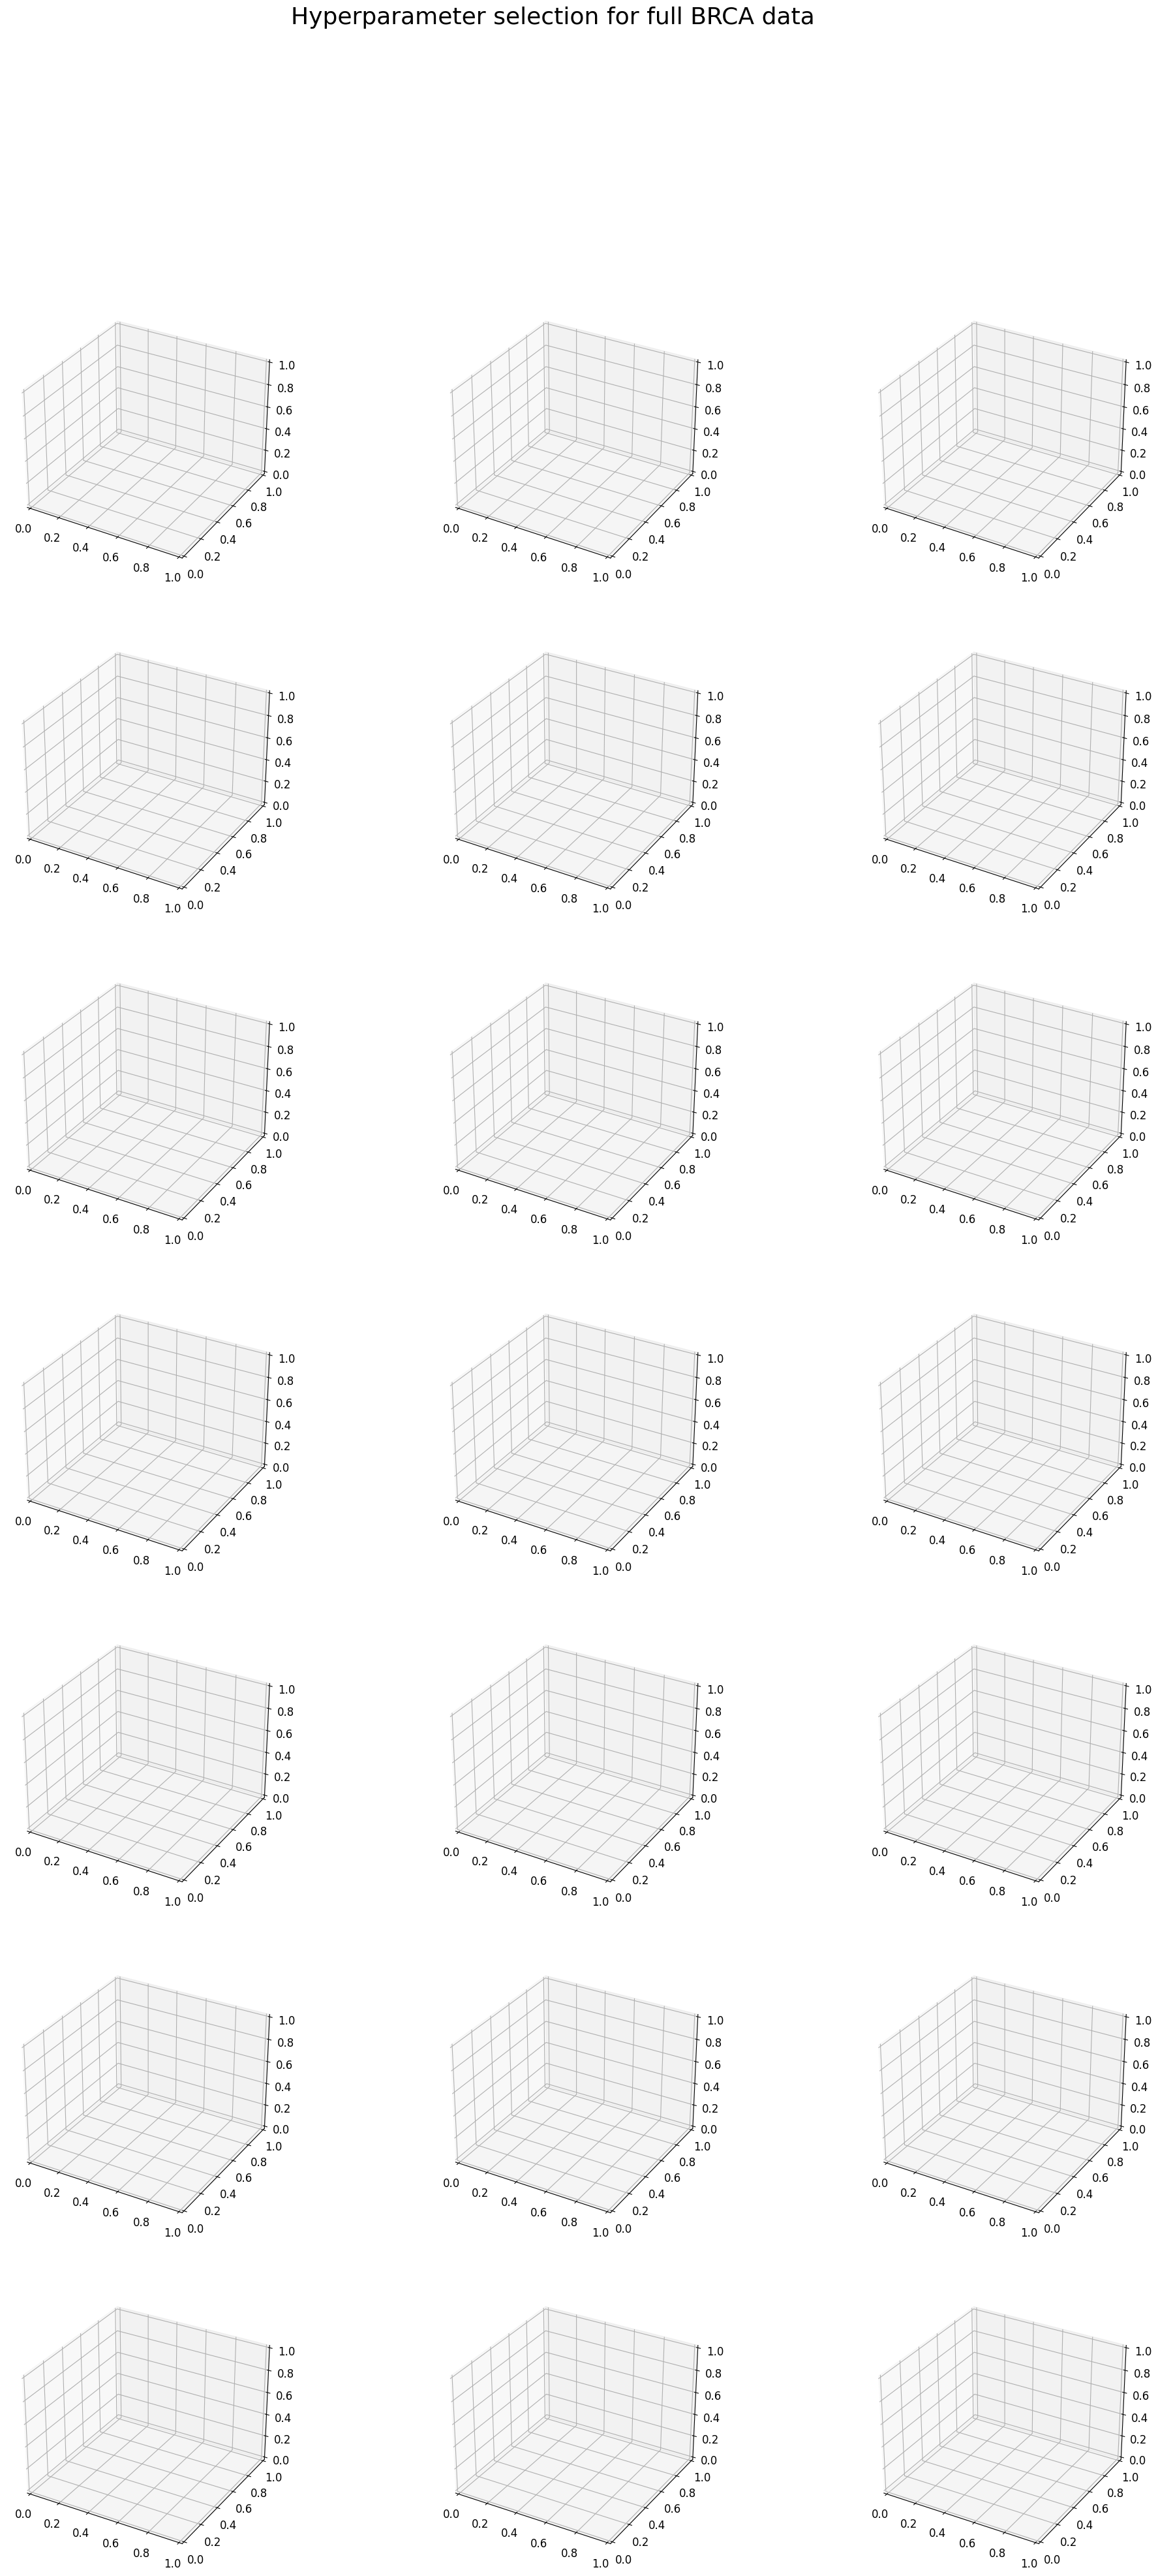

In [8]:
#FULL DATA - INCL. NEW MODELS
translate_lr = {0.00001:0, 0.0001:1, 0.001:2, 0.01:3, 0.1:4}

fig = plt.figure(figsize=(24,45))
fig.suptitle('Hyperparameter selection for full BRCA data', size=26)
ax = np.array([fig.add_subplot(7,3,j+3*(i-1), projection='3d') for i in range(1,8,1) for j in range(1,4,1)]).reshape(7,3)

max_val = 9
colors = plt.cm.rainbow(np.linspace(0, 1, max_val))
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(np.arange(max_val), cmap.N)
colorbar = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

plot_grid('MLP', MLP_inner_ext, MLP_outer_av, ax[0,0], cmap, norm)
plot_grid('mMLP', mMLP_inner_ext, mMLP_outer_av, ax[0,1], cmap, norm)
plot_grid('xMLP', xMLP_inner_ext, xMLP_outer_av, ax[0,2], cmap, norm)

#plot_grid('GCN', GCN_inner_ext, GCN_outer_av, ax[1,0], cmap, norm)
plot_grid('mGCN', mGCN_inner_ext, mGCN_outer_av, ax[1,1], cmap, norm)
#plot_grid('xGCN', xGCN_inner_ext, xGCN_outer_av, ax[1,2], cmap, norm)

#plot_grid_gat('GAT', GAT_inner_ext, GAT_outer_av, ax[2,0], cmap, norm)
#plot_grid_gat('mGAT', mGAT_inner_ext, mGAT_outer_av, ax[2,1], cmap, norm)
#plot_grid_gat('xGAT', xGAT_inner_ext, xGAT_outer_av, ax[2,2], cmap, norm)

#plot_grid('ChebNet', ChebNet_inner_ext, ChebNet_outer_av, ax[3,0], cmap, norm)
#plot_grid('mChebNet', mChebNet_inner_ext, mChebNet_outer_av, ax[3,1], cmap, norm)
#plot_grid('xChebNet', xChebNet_inner_ext, xChebNet_outer_av, ax[3,2], cmap, norm)

plot_grid('GCN2MLP', GCN2MLP_inner_ext, GCN2MLP_outer_av, ax[4,0], cmap, norm)
plot_grid('mGCN2MLP', mGCN2MLP_inner_ext, mGCN2MLP_outer_av, ax[4,1], cmap, norm)
#plot_grid('xGCN2MLP', xGCN2MLP_inner_ext, xGCN2MLP_outer_av, ax[4,2], cmap, norm)

#plot_grid_gat('GAT2MLP', GAT2MLP_inner_ext, GAT2MLP_outer_av, ax[5,0], cmap, norm)
#plot_grid_gat('mGAT2MLP', mGAT2MLP_inner_ext, mGAT2MLP_outer_av, ax[5,1], cmap, norm)
#plot_grid_gat('xGAT2MLP', xGAT2MLP_inner_ext, xGAT2MLP_outer_av, ax[5,2], cmap, norm)

plot_grid('ChebNet2MLP', ChebNet2MLP_inner_ext, ChebNet2MLP_outer_av, ax[6,0], cmap, norm)
#plot_grid('mChebNet2MLP', mChebNet2MLP_inner_ext, mChebNet2MLP_outer_av, ax[6,1], cmap, norm)
#plot_grid('xChebNet2MLP', xChebNet2MLP_inner_ext, xChebNet2MLP_outer_av, ax[6,2], cmap, norm)

fig.subplots_adjust(right=0.85)
fig.subplots_adjust(bottom=-0.1)
fig.subplots_adjust()
cbar_ax = fig.add_axes([0.93, 0.3, 0.01, 0.4])
fig.colorbar(colorbar, cax=cbar_ax)

'''
plt.savefig(path+'/final_hyp_selection_full_extended.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/final_hyp_selection_full_extended.pdf', bbox_inches='tight')
'''
plt.show()

Text(0.5, 1.0, 'expression')

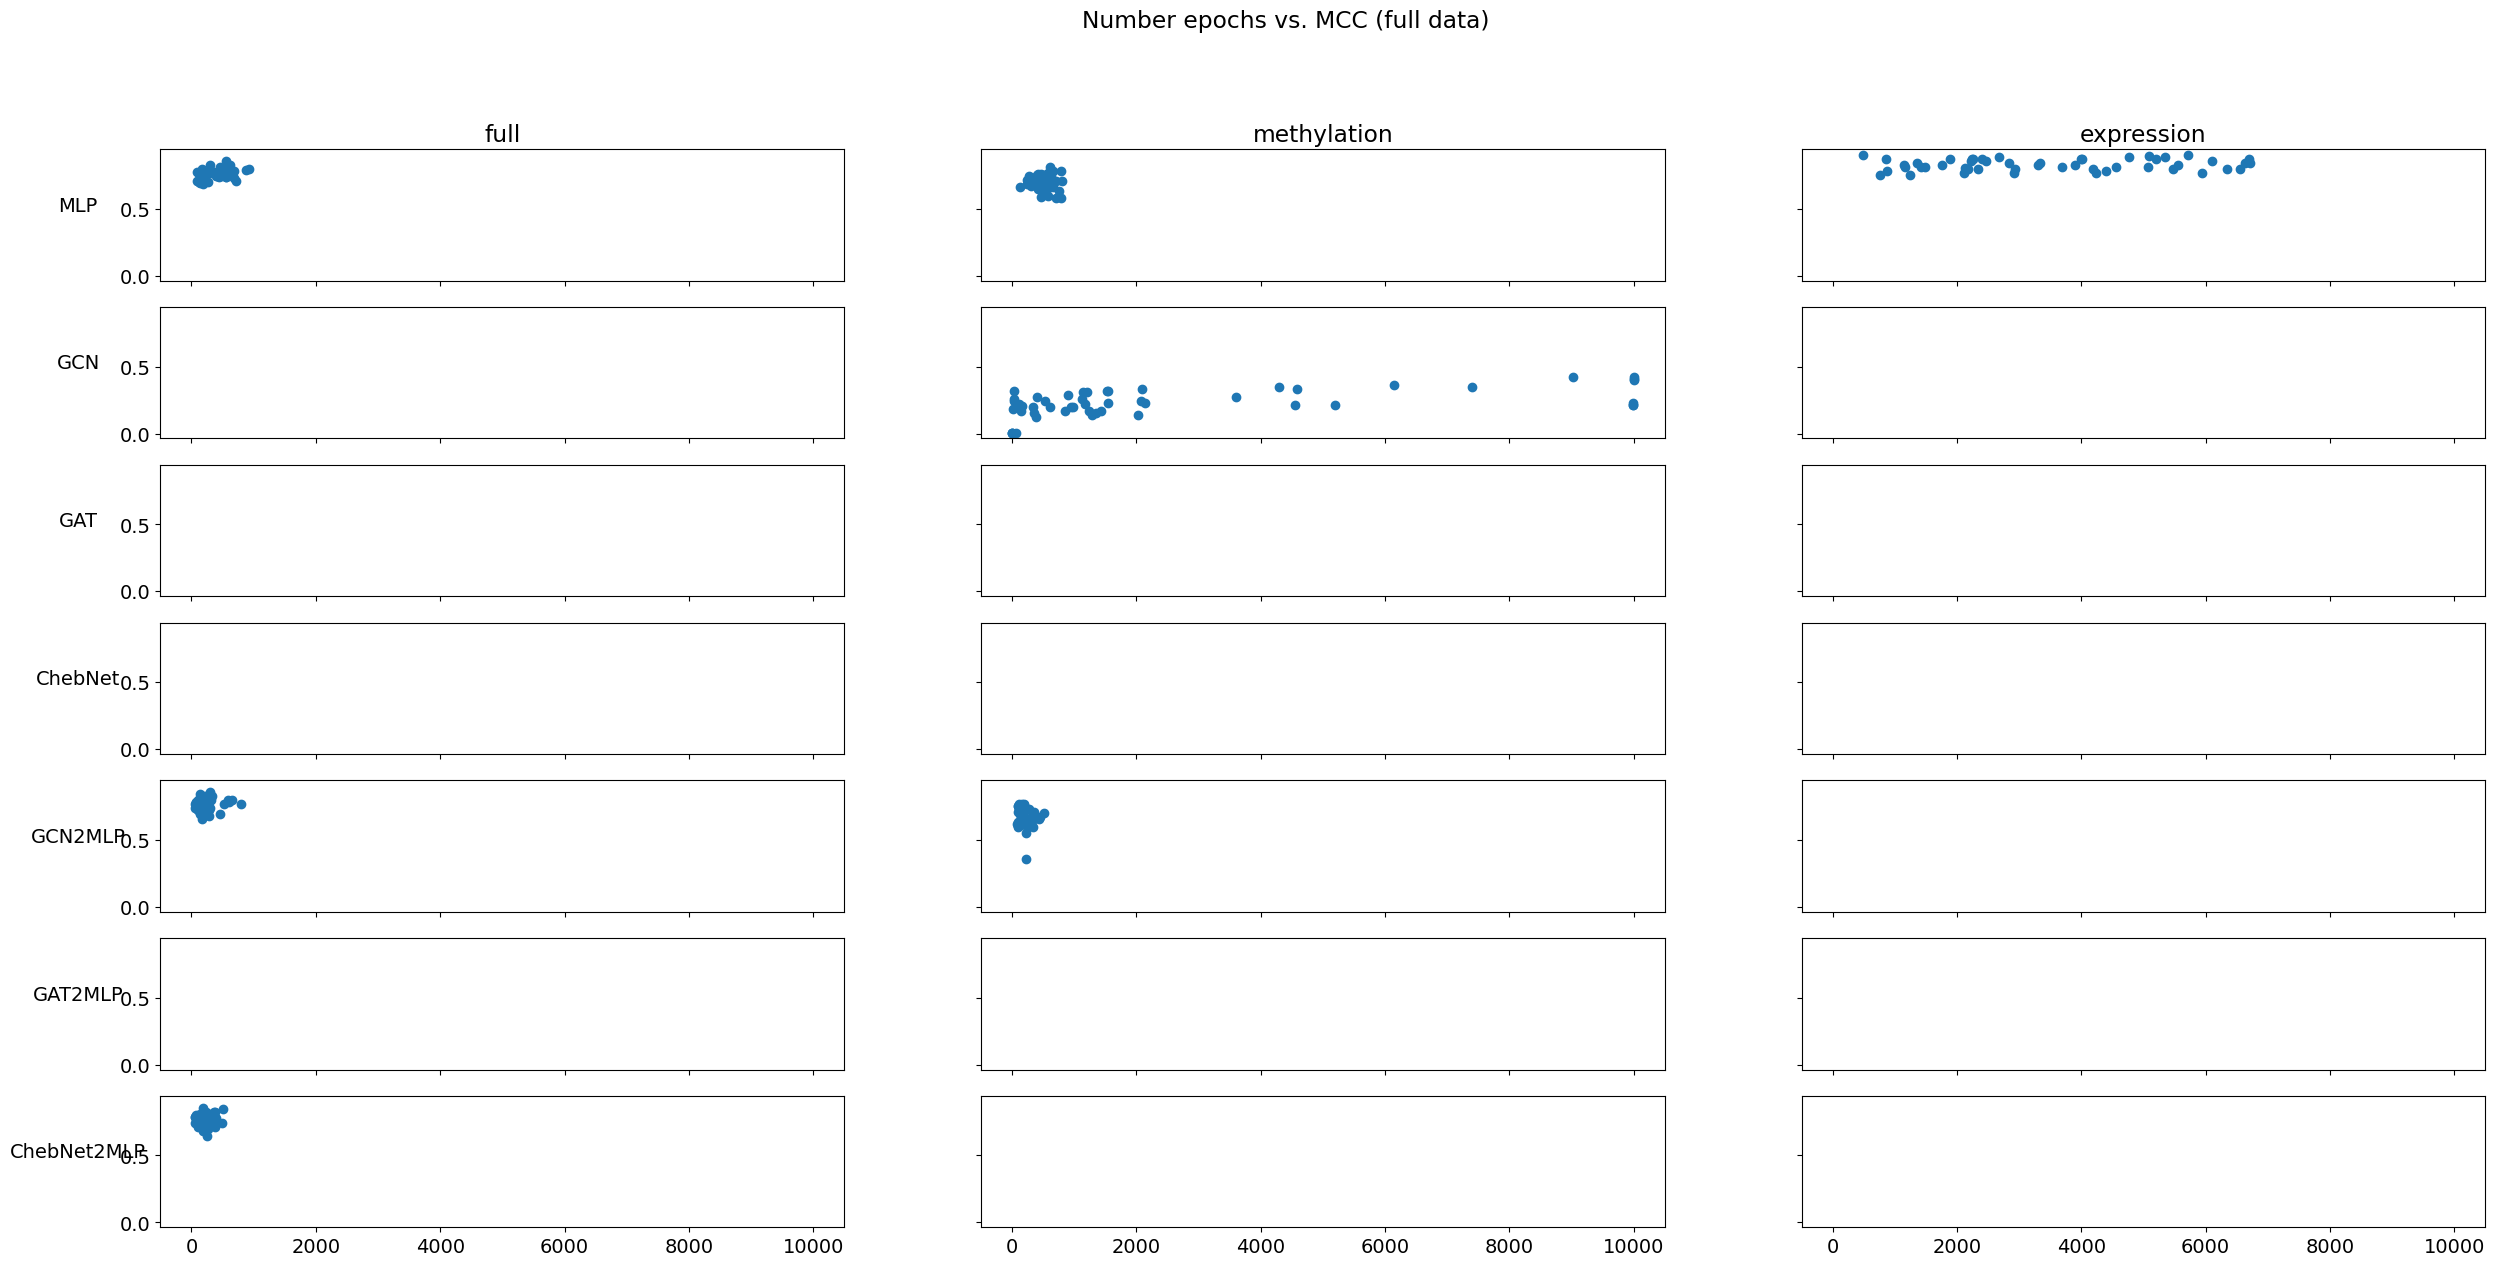

In [11]:
fig, ax = plt.subplots(ncols=3, nrows=7, figsize=(30,14), sharex=True, sharey=True)

fig.suptitle('Number epochs vs. MCC (full data)')

ax[0,0].scatter(MLP_outer_ext['number_epochs'], MLP_outer_ext['test_mcc'])
ax[0,1].scatter(mMLP_outer_ext['number_epochs'], mMLP_outer_ext['test_mcc'])
ax[0,2].scatter(xMLP_outer_ext['number_epochs'], xMLP_outer_ext['test_mcc'])

#ax[1,0].scatter(GCN_outer_ext['number_epochs'], GCN_outer_ext['test_mcc'])
ax[1,1].scatter(mGCN_outer_ext['number_epochs'], mGCN_outer_ext['test_mcc'])
#ax[1,2].scatter(xGCN_outer_ext['number_epochs'], xGCN_outer_ext['test_mcc'])

#ax[2,0].scatter(GAT_outer_ext['number_epochs'], GAT_outer_ext['test_mcc'])
#ax[2,1].scatter(mGAT_outer_ext['number_epochs'], mGAT_outer_ext['test_mcc'])
#ax[2,2].scatter(xGAT_outer_ext['number_epochs'], xGAT_outer_ext['test_mcc'])

#ax[3,0].scatter(ChebNet_outer_ext['number_epochs'], ChebNet_outer_ext['test_mcc'])
#ax[3,1].scatter(mChebNet_outer_ext['number_epochs'], mChebNet_outer_ext['test_mcc'])
#ax[3,2].scatter(xChebNet_outer_ext['number_epochs'], xChebNet_outer_ext['test_mcc'])

ax[4,0].scatter(GCN2MLP_outer_ext['number_epochs'], GCN2MLP_outer_ext['test_mcc'])
ax[4,1].scatter(mGCN2MLP_outer_ext['number_epochs'], mGCN2MLP_outer_ext['test_mcc'])
#ax[4,2].scatter(xGCN2MLP_outer_ext['number_epochs'], xGCN2MLP_outer_ext['test_mcc'])

#ax[5,0].scatter(GAT2MLP_outer_ext['number_epochs'], GAT2MLP_outer_ext['test_mcc'])
#ax[5,1].scatter(mGAT2MLP_outer_ext['number_epochs'], mGAT2MLP_outer_ext['test_mcc'])
#ax[5,2].scatter(xGAT2MLP_outer_ext['number_epochs'], xGAT2MLP_outer_ext['test_mcc'])

ax[6,0].scatter(ChebNet2MLP_outer_ext['number_epochs'], ChebNet2MLP_outer_ext['test_mcc'])
#ax[6,1].scatter(mChebNet2MLP_outer_ext['number_epochs'], mChebNet2MLP_outer_ext['test_mcc'])
#ax[6,2].scatter(xChebNet2MLP_outer_ext['number_epochs'], xChebNet2MLP_outer_ext['test_mcc'])


ax[0,0].set_ylabel('MLP', rotation=0, labelpad=30)
ax[1,0].set_ylabel('GCN', rotation=0, labelpad=30)
ax[2,0].set_ylabel('GAT', rotation=0, labelpad=30)
ax[3,0].set_ylabel('ChebNet', rotation=0, labelpad=30)
ax[4,0].set_ylabel('GCN2MLP', rotation=0, labelpad=30)
ax[5,0].set_ylabel('GAT2MLP', rotation=0, labelpad=30)
ax[6,0].set_ylabel('ChebNet2MLP', rotation=0, labelpad=30)
ax[0,0].set_title('full', rotation=0)
ax[0,1].set_title('methylation', rotation=0)
ax[0,2].set_title('expression', rotation=0)

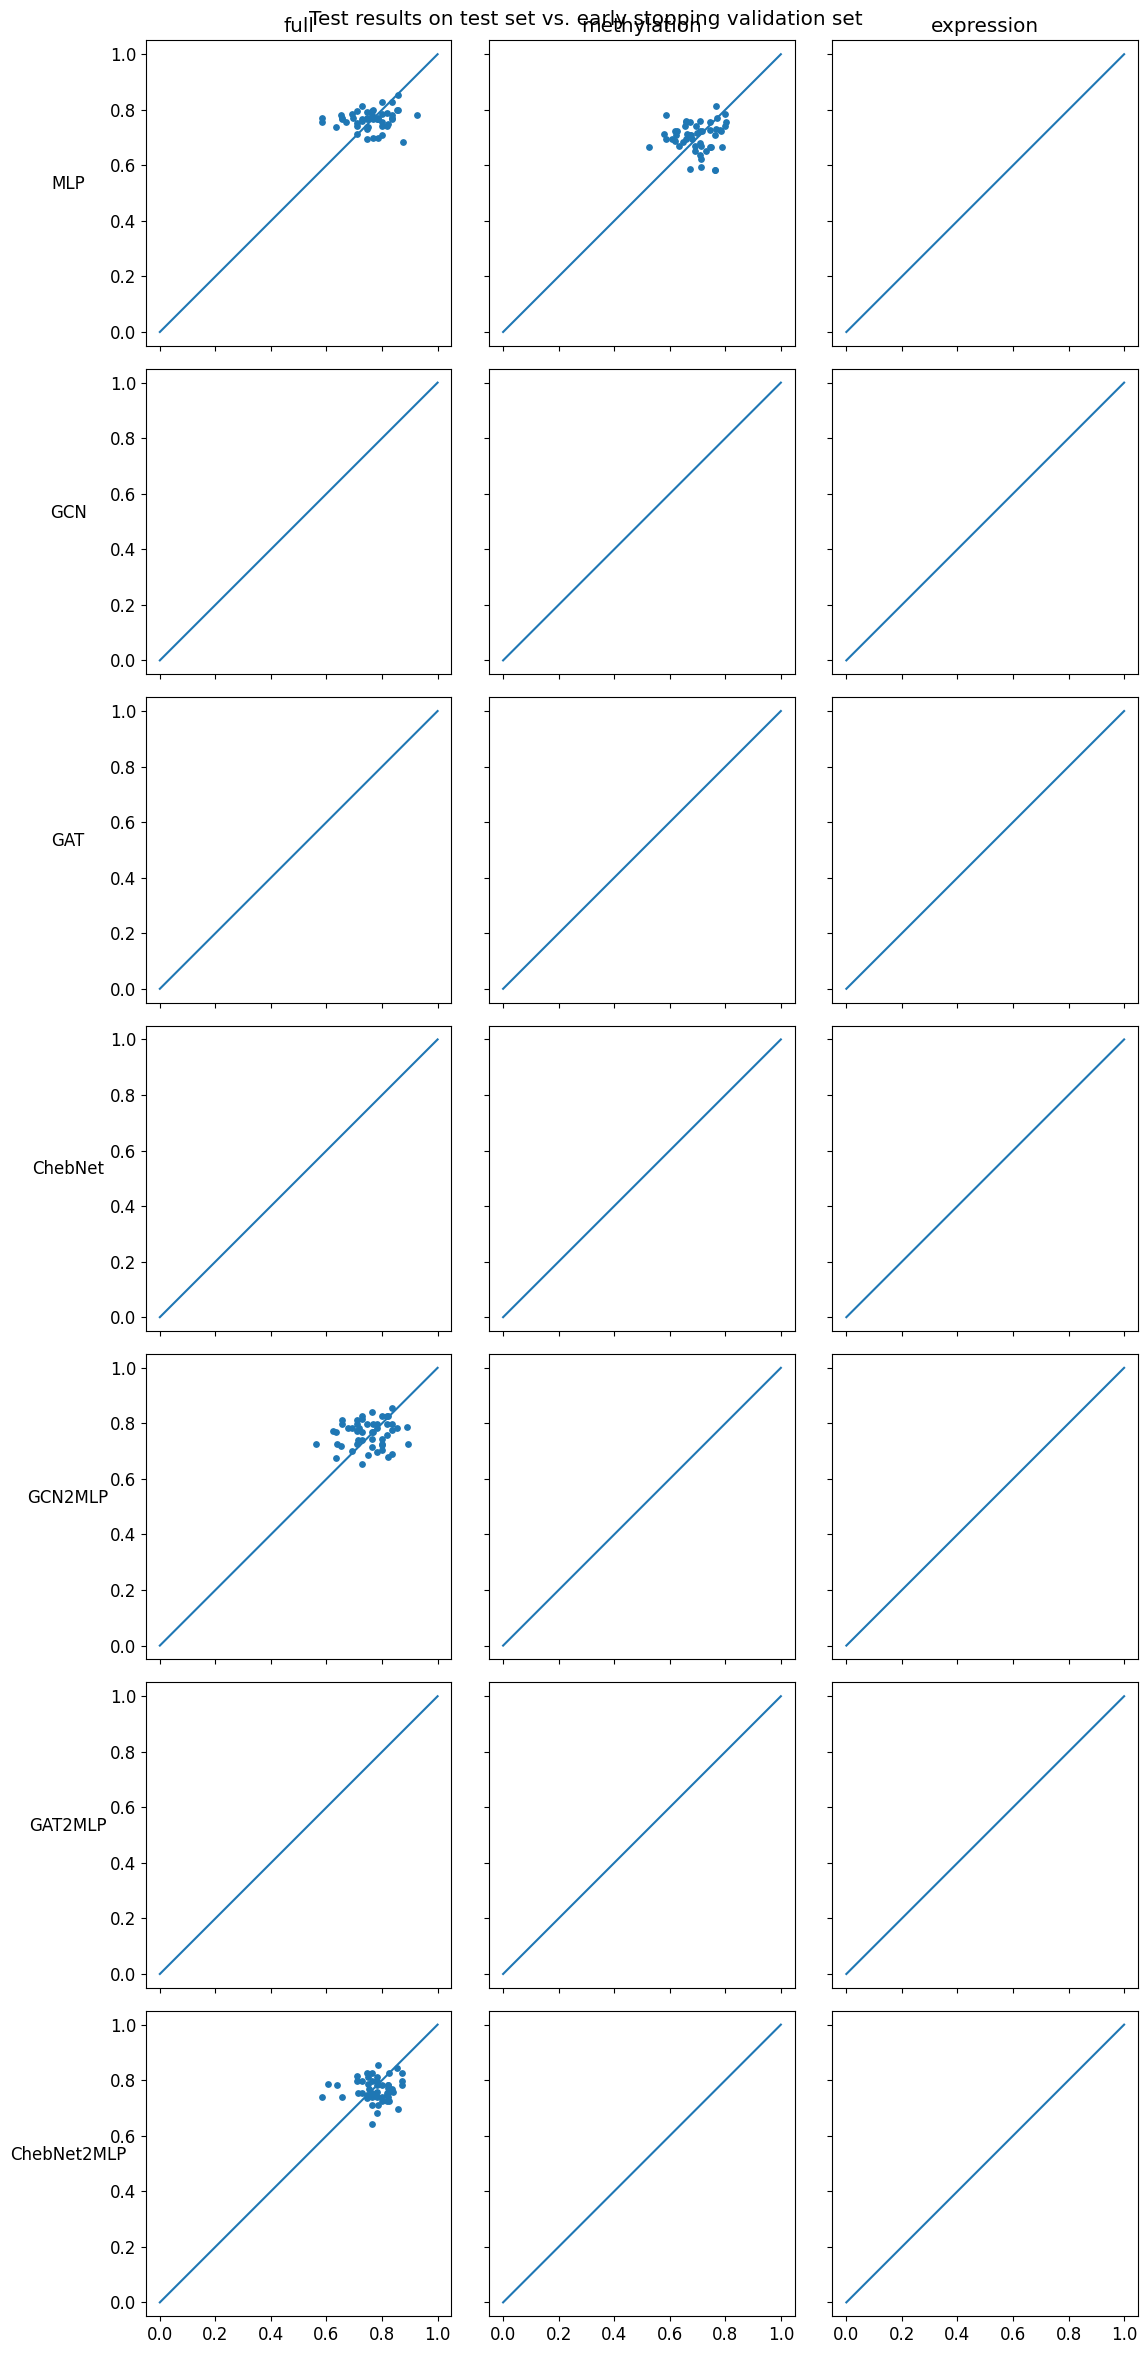

In [11]:
fig, ax = plt.subplots(ncols=3, nrows=7, figsize=(12,24), sharey=True, sharex=True)

ax[0,0].scatter(MLP_outer_ext['outer_es_mcc'], MLP_outer_ext['test_mcc'], s=15)
ax[0,1].scatter(mMLP_outer_ext['outer_es_mcc'], mMLP_outer_ext['test_mcc'],s=15)
#ax[0,2].scatter(xMLP_outer_ext['outer_es_mcc'], xMLP_outer_ext['test_mcc'],s=15)

#ax[1,0].scatter(GCN_outer_ext['outer_es_mcc'], GCN_outer_ext['test_mcc'],s=15)
#ax[1,1].scatter(mGCN_outer_ext['outer_es_mcc'], mGCN_outer_ext['test_mcc'],s=15)
#ax[1,2].scatter(xGCN_outer_ext['outer_es_mcc'], xGCN_outer_ext['test_mcc'],s=15)

#ax[2,0].scatter(GAT_outer_ext['outer_es_mcc'], GAT_outer_ext['test_mcc'],s=15)
#ax[2,1].scatter(mGAT_outer_ext['outer_es_mcc'], mGAT_outer_ext['test_mcc'],s=15)
#ax[2,2].scatter(xGAT_outer_ext['outer_es_mcc'], xGAT_outer_ext['test_mcc'],s=15)

#ax[3,0].scatter(ChebNet_outer_ext['outer_es_mcc'], ChebNet_outer_ext['test_mcc'],s=15)
#ax[3,1].scatter(mChebNet_outer_ext['outer_es_mcc'], mChebNet_outer_ext['test_mcc'],s=15)
#ax[3,2].scatter(xChebNet_outer_ext['outer_es_mcc'], xChebNet_outer_ext['test_mcc'],s=15)

ax[4,0].scatter(GCN2MLP_outer_ext['outer_es_mcc'], GCN2MLP_outer_ext['test_mcc'],s=15)
#ax[4,1].scatter(mGCN2MLP_outer_ext['outer_es_mcc'], mGCN2MLP_outer_ext['test_mcc'],s=15)
#ax[4,2].scatter(xGCN2MLP_outer_ext['outer_es_mcc'], xGCN2MLP_outer_ext['test_mcc'],s=15)

#ax[5,0].scatter(GAT2MLP_outer_ext['outer_es_mcc'], GAT2MLP_outer_ext['test_mcc'],s=15)
#ax[5,1].scatter(mGAT2MLP_outer_ext['outer_es_mcc'], mGAT2MLP_outer_ext['test_mcc'],s=15)
#ax[5,2].scatter(xGAT2MLP_outer_ext['outer_es_mcc'], xGAT2MLP_outer_ext['test_mcc'],s=15)

ax[6,0].scatter(ChebNet2MLP_outer_ext['outer_es_mcc'], ChebNet2MLP_outer_ext['test_mcc'],s=15)
#ax[6,1].scatter(mChebNet2MLP_outer_ext['outer_es_mcc'], mChebNet2MLP_outer_ext['test_mcc'],s=15)
#ax[6,2].scatter(xChebNet2MLP_outer_ext['outer_es_mcc'], xChebNet2MLP_outer_ext['test_mcc'],s=15)

ax[0,0].set_aspect('equal', adjustable='box')
ax[0,1].set_aspect('equal', adjustable='box')
ax[0,2].set_aspect('equal', adjustable='box')
ax[1,0].set_aspect('equal', adjustable='box')
ax[1,1].set_aspect('equal', adjustable='box')
ax[1,2].set_aspect('equal', adjustable='box')
ax[2,0].set_aspect('equal', adjustable='box')
ax[2,1].set_aspect('equal', adjustable='box')
ax[2,2].set_aspect('equal', adjustable='box')
ax[3,0].set_aspect('equal', adjustable='box')
ax[3,1].set_aspect('equal', adjustable='box')
ax[3,2].set_aspect('equal', adjustable='box')
ax[4,0].set_aspect('equal', adjustable='box')
ax[4,1].set_aspect('equal', adjustable='box')
ax[4,2].set_aspect('equal', adjustable='box')
ax[5,0].set_aspect('equal', adjustable='box')
ax[5,1].set_aspect('equal', adjustable='box')
ax[5,2].set_aspect('equal', adjustable='box')
ax[6,0].set_aspect('equal', adjustable='box')
ax[6,1].set_aspect('equal', adjustable='box')
ax[6,2].set_aspect('equal', adjustable='box')

ax[0,0].set_ylabel('MLP', rotation=0, labelpad=30)
ax[1,0].set_ylabel('GCN', rotation=0, labelpad=30)
ax[2,0].set_ylabel('GAT', rotation=0, labelpad=30)
ax[3,0].set_ylabel('ChebNet', rotation=0, labelpad=30)
ax[4,0].set_ylabel('GCN2MLP', rotation=0, labelpad=30)
ax[5,0].set_ylabel('GAT2MLP', rotation=0, labelpad=30)
ax[6,0].set_ylabel('ChebNet2MLP', rotation=0, labelpad=30)
ax[0,0].set_title('full', rotation=0)
ax[0,1].set_title('methylation', rotation=0)
ax[0,2].set_title('expression', rotation=0)

ax[0,0].plot([0,1], [0,1])
ax[0,1].plot([0,1], [0,1])
ax[0,2].plot([0,1], [0,1])
ax[1,0].plot([0,1], [0,1])
ax[1,1].plot([0,1], [0,1])
ax[1,2].plot([0,1], [0,1])
ax[2,0].plot([0,1], [0,1])
ax[2,1].plot([0,1], [0,1])
ax[2,2].plot([0,1], [0,1])
ax[3,0].plot([0,1], [0,1])
ax[3,1].plot([0,1], [0,1])
ax[3,2].plot([0,1], [0,1])
ax[4,0].plot([0,1], [0,1])
ax[4,1].plot([0,1], [0,1])
ax[4,2].plot([0,1], [0,1])
ax[5,0].plot([0,1], [0,1])
ax[5,1].plot([0,1], [0,1])
ax[5,2].plot([0,1], [0,1])
ax[6,0].plot([0,1], [0,1])
ax[6,1].plot([0,1], [0,1])
ax[6,2].plot([0,1], [0,1])

fig.suptitle('Test results on test set vs. early stopping validation set')
plt.tight_layout()
plt.show()

## Additional Plots for Paper (copied from KIRC)

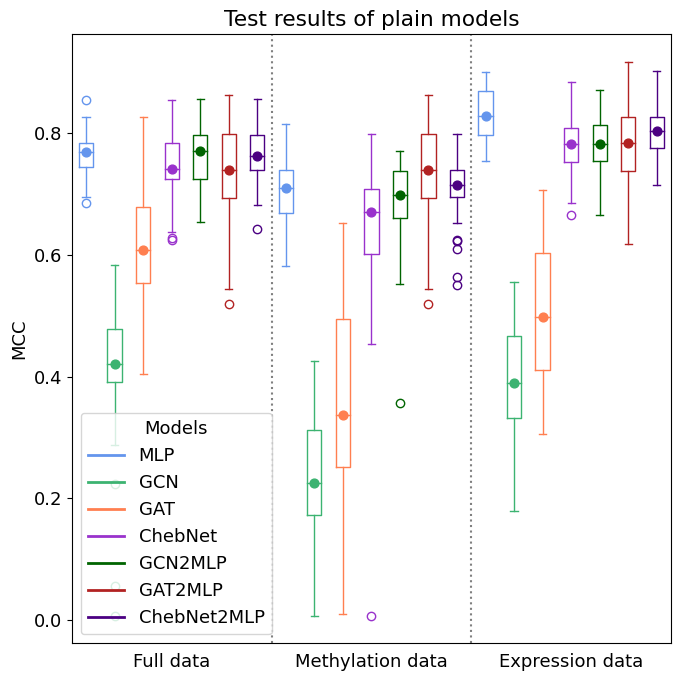

In [ ]:
# All models, incl. new models (GCN/GAT2MLP) - MCC box plots
mpl.rcParams.update({'font.size': 13})

colors = ['cornflowerblue', 'mediumseagreen', 'coral', 'darkorchid', 'darkgreen', 'firebrick', 'indigo' ]
symbols = ['o'] 



data = [    MLP_outer_ext['test_mcc'],
            GCN_outer_ext['test_mcc'],
            GAT_outer_ext['test_mcc'],
            ChebNet_outer_ext['test_mcc'],
            GCN2MLP_outer_ext['test_mcc'],
            GAT2MLP_outer_ext['test_mcc'],
            ChebNet2MLP_outer_ext['test_mcc'],
            mMLP_outer_ext['test_mcc'],
            mGCN_outer_ext['test_mcc'],
            mGAT_outer_ext['test_mcc'],
            mChebNet_outer_ext['test_mcc'],
            mGCN2MLP_outer_ext['test_mcc'],
            mGAT2MLP_outer_ext['test_mcc'],
            mChebNet2MLP_outer_ext['test_mcc'],
            xMLP_outer_ext['test_mcc'],
            xGCN_outer_ext['test_mcc'],
            xGAT_outer_ext['test_mcc'],
            xChebNet_outer_ext['test_mcc'],
            xGCN2MLP_outer_ext['test_mcc'],
            xGAT2MLP_outer_ext['test_mcc'],
            xChebNet2MLP_outer_ext['test_mcc'],
            ]

fig, ax = plt.subplots(figsize=(7, 7))
bp = ax.boxplot(data, showcaps=True)

for i in range(len(bp['boxes'])):
    group_color = colors[(i // 1)%7] 

    bp['boxes'][i].set(color=group_color, linewidth=1)
    bp['caps'][2 * i].set(color=group_color, linewidth=1)    
    bp['caps'][2 * i + 1].set(color=group_color, linewidth=1)  
    bp['whiskers'][2 * i].set(color=group_color, linewidth=1)     
    bp['whiskers'][2 * i + 1].set(color=group_color, linewidth=1) 

    median = np.median(data[i])
    ax.scatter(i + 1, median, color=group_color, s=40, marker=symbols[0], zorder=3)
    bp['medians'][i].set(color=group_color, linewidth=1)
    bp['fliers'][i].set(markeredgecolor=group_color)

plt.axvline(x=7.5, color='grey', linestyle=':')
plt.axvline(x=14.5, color='grey', linestyle=':')

groups_colors = ['MLP', 'GCN', 'GAT', 'ChebNet', 'GCN2MLP', 'GAT2MLP', 'ChebNet2MLP']
groups_shapes = ['Plain']

legend_handles = [
                    Line2D([0], [0], color=color, lw=2, label=name)
                    for color, name in zip(colors, groups_colors)
                ]

ax.legend(handles=legend_handles, title='Models')
ax.set_xticks([])
ax.set_ylabel('MCC')

ax.set_xticks([4, 11, 18],['Full data', 'Methylation data', 'Expression data'] )
ax.xaxis.set_ticks_position('none') 
ax.set_title('Test results of plain models')

plt.tight_layout()

plt.savefig(path+'/final_box_metric_plain.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/final_box_metric_plain.pdf', bbox_inches='tight')

plt.show()


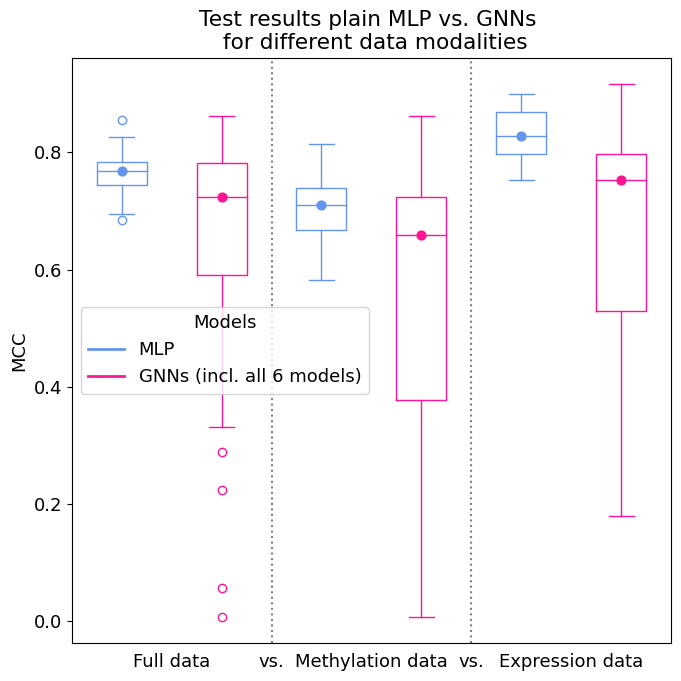

In [34]:
# All models - MCC box plots, all GNN models in one box (but all plain!)

colors = ['cornflowerblue', 'deeppink' ]
symbols = ['o'] 



data = [    MLP_outer_ext['test_mcc'],
            pd.concat([GCN_outer_ext['test_mcc'],
            GAT_outer_ext['test_mcc'],
            ChebNet_outer_ext['test_mcc'],
            GCN2MLP_outer_ext['test_mcc'],
            GAT2MLP_outer_ext['test_mcc'],
            ChebNet2MLP_outer_ext['test_mcc']]),
            mMLP_outer_ext['test_mcc'],
            pd.concat([mGCN_outer_ext['test_mcc'],
            mGAT_outer_ext['test_mcc'],
            mChebNet_outer_ext['test_mcc'],
            mGCN2MLP_outer_ext['test_mcc'],
            mGAT2MLP_outer_ext['test_mcc'],
            mChebNet2MLP_outer_ext['test_mcc']]),
            xMLP_outer_ext['test_mcc'],
            pd.concat([xGCN_outer_ext['test_mcc'],
            xGAT_outer_ext['test_mcc'],
            xChebNet_outer_ext['test_mcc'],
            xGCN2MLP_outer_ext['test_mcc'],
            xGAT2MLP_outer_ext['test_mcc'],
            xChebNet2MLP_outer_ext['test_mcc']]),
            ]

fig, ax = plt.subplots(figsize=(7,7))
bp = ax.boxplot(data, showcaps=True)

for i in range(len(bp['boxes'])):
    group_color = colors[(i // 1)%2] 

    bp['boxes'][i].set(color=group_color, linewidth=1)
    bp['caps'][2 * i].set(color=group_color, linewidth=1)    
    bp['caps'][2 * i + 1].set(color=group_color, linewidth=1)  
    bp['whiskers'][2 * i].set(color=group_color, linewidth=1)     
    bp['whiskers'][2 * i + 1].set(color=group_color, linewidth=1) 

    median = np.median(data[i])
    ax.scatter(i + 1, median, color=group_color, s=40, marker=symbols[0], zorder=3)
    bp['medians'][i].set(color=group_color, linewidth=1)
    bp['fliers'][i].set(markeredgecolor=group_color)

plt.axvline(x=2.5, color='grey', linestyle=':')
plt.axvline(x=4.5, color='grey', linestyle=':')

groups_colors = ['MLP', 'GNNs (incl. all 6 models)']
groups_shapes = ['Plain']

legend_handles = [
                    Line2D([0], [0], color=color, lw=2, label=name)
                    for color, name in zip(colors, groups_colors)
                ]

ax.legend(handles=legend_handles, title='Models')
ax.set_xticks([])
ax.set_ylabel('MCC')

ax.set_xticks([1.5,2.5, 3.5,4.5, 5.5],['Full data', 'vs.', 'Methylation data','vs.', 'Expression data'] )
ax.xaxis.set_ticks_position('none') 
ax.set_title('Test results plain MLP vs. GNNs \n for different data modalities')



plt.tight_layout()

plt.savefig(path+'/final_box_metric_data.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/final_box_metric_data.pdf', bbox_inches='tight')

plt.show()


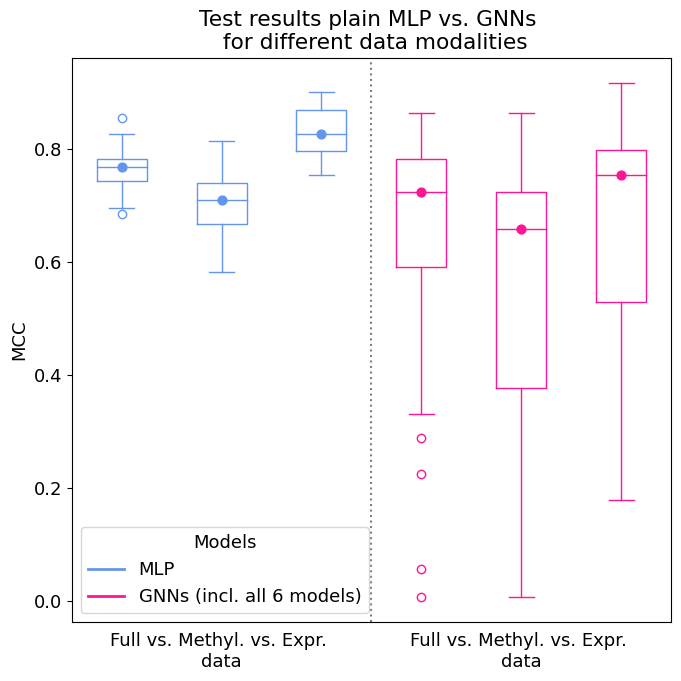

In [35]:
# VERSION 2
# All models - MCC box plots, all GNN models in one box (but all plain!)

colors = ['cornflowerblue', 'deeppink' ]
symbols = ['o'] 



data = [    MLP_outer_ext['test_mcc'],
            mMLP_outer_ext['test_mcc'],
            xMLP_outer_ext['test_mcc'],
            pd.concat([GCN_outer_ext['test_mcc'],
            GAT_outer_ext['test_mcc'],
            ChebNet_outer_ext['test_mcc'],
            GCN2MLP_outer_ext['test_mcc'],
            GAT2MLP_outer_ext['test_mcc'],
            ChebNet2MLP_outer_ext['test_mcc']]),
            pd.concat([mGCN_outer_ext['test_mcc'],
            mGAT_outer_ext['test_mcc'],
            mChebNet_outer_ext['test_mcc'],
            mGCN2MLP_outer_ext['test_mcc'],
            mGAT2MLP_outer_ext['test_mcc'],
            mChebNet2MLP_outer_ext['test_mcc']]),
            pd.concat([xGCN_outer_ext['test_mcc'],
            xGAT_outer_ext['test_mcc'],
            xChebNet_outer_ext['test_mcc'],
            xGCN2MLP_outer_ext['test_mcc'],
            xGAT2MLP_outer_ext['test_mcc'],
            xChebNet2MLP_outer_ext['test_mcc']]),
            ]

fig, ax = plt.subplots(figsize=(7,7))
bp = ax.boxplot(data, showcaps=True)

for i in range(len(bp['boxes'])):
    group_color = colors[(i // 3)%3] 

    bp['boxes'][i].set(color=group_color, linewidth=1)
    bp['caps'][2 * i].set(color=group_color, linewidth=1)    
    bp['caps'][2 * i + 1].set(color=group_color, linewidth=1)  
    bp['whiskers'][2 * i].set(color=group_color, linewidth=1)     
    bp['whiskers'][2 * i + 1].set(color=group_color, linewidth=1) 

    median = np.median(data[i])
    ax.scatter(i + 1, median, color=group_color, s=40, marker=symbols[0], zorder=3)
    bp['medians'][i].set(color=group_color, linewidth=1)
    bp['fliers'][i].set(markeredgecolor=group_color)

plt.axvline(x=3.5, color='grey', linestyle=':')

groups_colors = ['MLP', 'GNNs (incl. all 6 models)']
groups_shapes = ['Plain']

legend_handles = [
                    Line2D([0], [0], color=color, lw=2, label=name)
                    for color, name in zip(colors, groups_colors)
                ]

ax.legend(handles=legend_handles, title='Models')
ax.set_xticks([])
ax.set_ylabel('MCC')

ax.set_xticks([2, 5],['Full vs. Methyl. vs. Expr. \ndata', 'Full vs. Methyl. vs. Expr. \ndata'] )
ax.xaxis.set_ticks_position('none') 
ax.set_title('Test results plain MLP vs. GNNs \n for different data modalities')



plt.tight_layout()

plt.savefig(path+'/final_box_metric_data_2.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/final_box_metric_data_2.pdf', bbox_inches='tight')

plt.show()


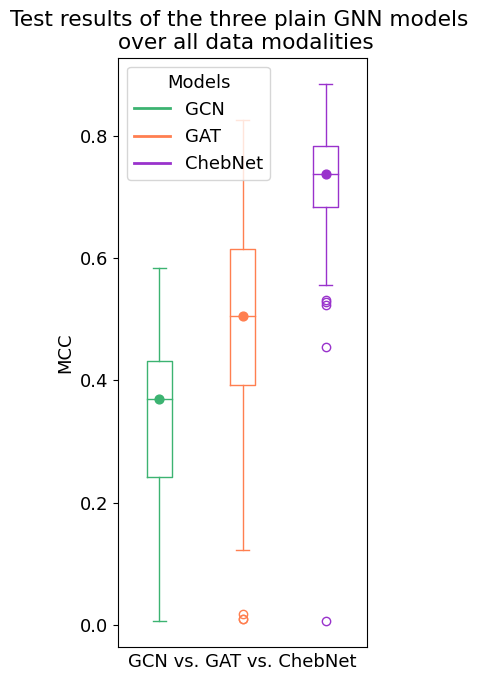

In [36]:
# All models - MCC box plots, all data modalities in one box (but all plain!)

colors = ['mediumseagreen', 'coral', 'darkorchid' ]
symbols = ['o'] 



data = [pd.concat([GCN_outer_ext['test_mcc'],
                   mGCN_outer_ext['test_mcc'],
                   xGCN_outer_ext['test_mcc']]),
        pd.concat([GAT_outer_ext['test_mcc'],
                   mGAT_outer_ext['test_mcc'],
                   xGAT_outer_ext['test_mcc']]),
        pd.concat([ChebNet_outer_ext['test_mcc'],
                   mChebNet_outer_ext['test_mcc'],
                   xChebNet_outer_ext['test_mcc']])]

fig, ax = plt.subplots(figsize=(3.5,7))
bp = ax.boxplot(data, showcaps=True)

for i in range(len(bp['boxes'])):
    group_color = colors[(i // 1)%3] 

    bp['boxes'][i].set(color=group_color, linewidth=1)
    bp['caps'][2 * i].set(color=group_color, linewidth=1)    
    bp['caps'][2 * i + 1].set(color=group_color, linewidth=1)  
    bp['whiskers'][2 * i].set(color=group_color, linewidth=1)     
    bp['whiskers'][2 * i + 1].set(color=group_color, linewidth=1) 

    median = np.median(data[i])
    ax.scatter(i + 1, median, color=group_color, s=40, marker=symbols[0], zorder=3)
    bp['medians'][i].set(color=group_color, linewidth=1)
    bp['fliers'][i].set(markeredgecolor=group_color)

#plt.axvline(x=2.5, color='grey', linestyle=':')
#plt.axvline(x=4.5, color='grey', linestyle=':')

groups_colors = ['GCN', 'GAT', 'ChebNet']
groups_shapes = ['Plain']

legend_handles = [
                    Line2D([0], [0], color=color, lw=2, label=name)
                    for color, name in zip(colors, groups_colors)
                ]

ax.legend(handles=legend_handles, title='Models')
ax.set_xticks([])
ax.set_ylabel('MCC')
ax.set_xlabel('GCN vs. GAT vs. ChebNet')


#ax.set_xticks([1.5, 3.5, 5.5],['Full data', 'Methylation data', 'Expression data'] )
ax.xaxis.set_ticks_position('none') 
ax.set_title('Test results of the three plain GNN models \n over all data modalities')



plt.tight_layout()

plt.savefig(path+'/final_box_metric_models.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/final_box_metric_models.pdf', bbox_inches='tight')

plt.show()


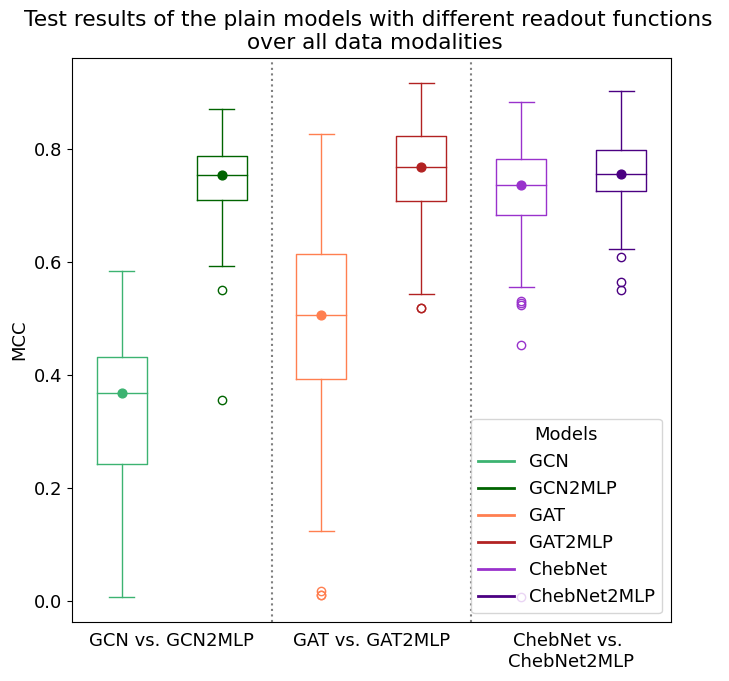

In [37]:
# All models - MCC box plots, all GNN models in one box (but all plain!)
mpl.rcParams.update({'font.size': 13})
colors = ['mediumseagreen', 'darkgreen', 'coral', 'firebrick', 'darkorchid', 'indigo' ]
symbols = ['o'] 


data = [pd.concat([GCN_outer_ext['test_mcc'],
                   mGCN_outer_ext['test_mcc'],
                   xGCN_outer_ext['test_mcc']]),
        pd.concat([GCN2MLP_outer_ext['test_mcc'],
                   mGCN2MLP_outer_ext['test_mcc'],
                   xGCN2MLP_outer_ext['test_mcc']]),
        pd.concat([GAT_outer_ext['test_mcc'],
                   mGAT_outer_ext['test_mcc'],
                   xGAT_outer_ext['test_mcc']]),
        pd.concat([GAT2MLP_outer_ext['test_mcc'],
                   mGAT2MLP_outer_ext['test_mcc'],
                   xGAT2MLP_outer_ext['test_mcc']]),
        pd.concat([ChebNet_outer_ext['test_mcc'],
                   mChebNet_outer_ext['test_mcc'],
                   xChebNet_outer_ext['test_mcc']]),
        pd.concat([ChebNet2MLP_outer_ext['test_mcc'],
                   mChebNet2MLP_outer_ext['test_mcc'],
                   xChebNet2MLP_outer_ext['test_mcc']])]

fig, ax = plt.subplots(figsize=(7,7))
bp = ax.boxplot(data, showcaps=True)

for i in range(len(bp['boxes'])):
    group_color = colors[(i // 1)%6] 

    bp['boxes'][i].set(color=group_color, linewidth=1)
    bp['caps'][2 * i].set(color=group_color, linewidth=1)    
    bp['caps'][2 * i + 1].set(color=group_color, linewidth=1)  
    bp['whiskers'][2 * i].set(color=group_color, linewidth=1)     
    bp['whiskers'][2 * i + 1].set(color=group_color, linewidth=1) 

    median = np.median(data[i])
    ax.scatter(i + 1, median, color=group_color, s=40, marker=symbols[0], zorder=3)
    bp['medians'][i].set(color=group_color, linewidth=1)
    bp['fliers'][i].set(markeredgecolor=group_color)

plt.axvline(x=2.5, color='grey', linestyle=':')
plt.axvline(x=4.5, color='grey', linestyle=':')

groups_colors = ['GCN', 'GCN2MLP', 'GAT', 'GAT2MLP', 'ChebNet', 'ChebNet2MLP']
groups_shapes = ['Plain']

legend_handles = [
                    Line2D([0], [0], color=color, lw=2, label=name)
                    for color, name in zip(colors, groups_colors)
                ]

ax.legend(handles=legend_handles, title='Models')
ax.set_xticks([])
ax.set_ylabel('MCC')

ax.set_xticks([1.5, 3.5, 5.5],['GCN vs. GCN2MLP', 'GAT vs. GAT2MLP', 'ChebNet vs. \nChebNet2MLP'] )
ax.xaxis.set_ticks_position('none') 
ax.set_title('Test results of the plain models with different readout functions \n over all data modalities')



plt.tight_layout()

plt.savefig(path+'/final_box_metric_readout.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/final_box_metric_readout.pdf', bbox_inches='tight')

plt.show()


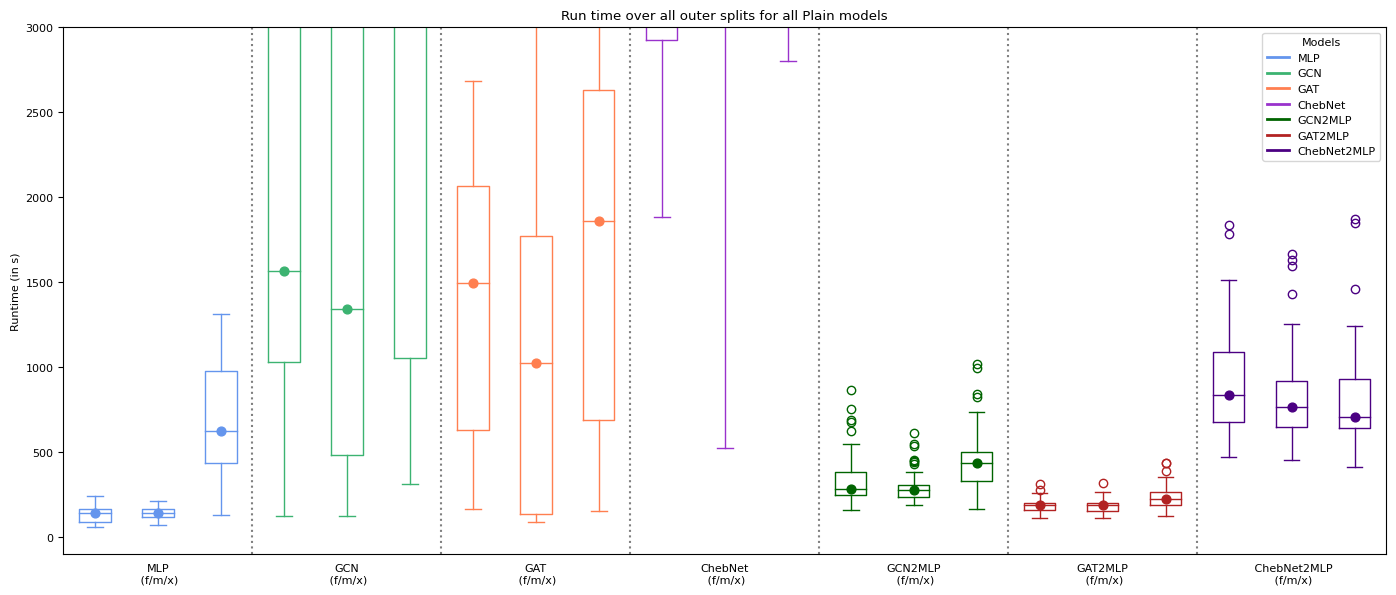

In [38]:
# RUNTIME
mpl.rcParams.update({'font.size': 8})

colors = ['cornflowerblue', 'mediumseagreen', 'coral', 'darkorchid', 'darkgreen', 'firebrick', 'indigo' ]
symbols = ['o', '^', 's'] 

data = [    MLP_outer_ext['time_total_s'],
            mMLP_outer_ext['time_total_s'],
            xMLP_outer_ext['time_total_s'],
            GCN_outer_ext['time_total_s'],
            mGCN_outer_ext['time_total_s'],
            xGCN_outer_ext['time_total_s'],
            GAT_outer_ext['time_total_s'],
            mGAT_outer_ext['time_total_s'],
            xGAT_outer_ext['time_total_s'],
            ChebNet_outer_ext['time_total_s'],
            mChebNet_outer_ext['time_total_s'],
            xChebNet_outer_ext['time_total_s'],
            GCN2MLP_outer_ext['time_total_s'],
            mGCN2MLP_outer_ext['time_total_s'],
            xGCN2MLP_outer_ext['time_total_s'],
            GAT2MLP_outer_ext['time_total_s'],
            mGAT2MLP_outer_ext['time_total_s'],
            xGAT2MLP_outer_ext['time_total_s'],
            ChebNet2MLP_outer_ext['time_total_s'],
            mChebNet2MLP_outer_ext['time_total_s'],
            xChebNet2MLP_outer_ext['time_total_s']
            ]

group_colors = [colors[0],colors[0],colors[0],
                colors[1],colors[1],colors[1],
                colors[2],colors[2],colors[2],
                colors[3],colors[3],colors[3],
                colors[4],colors[4],colors[4],
                colors[5],colors[5],colors[5],
                colors[6],colors[6],colors[6],
                colors[0],
                colors[1], colors[2], colors[3], colors[4], colors[5], colors[6],
                colors[1], colors[2], colors[3], colors[4], colors[5], colors[6],
                colors[1], colors[2], colors[3], colors[4], colors[5], colors[6],
                colors[1], colors[2], colors[3], colors[4], colors[5], colors[6]]

group_symbols = [symbols[0],symbols[0],symbols[0],
                 symbols[0],symbols[0],symbols[0],
                 symbols[0],symbols[0],symbols[0],
                 symbols[0],symbols[0],symbols[0],
                 symbols[0],symbols[0],symbols[0],
                 symbols[0],symbols[0],symbols[0],
                 symbols[0],symbols[0],symbols[0],
                 symbols[0],
                 symbols[0],symbols[0],symbols[0],symbols[0],symbols[0],symbols[0],
                 symbols[0],symbols[0],symbols[0],symbols[0],symbols[0],symbols[0],
                 symbols[0],symbols[0],symbols[0],symbols[0],symbols[0],symbols[0],
                 symbols[0],symbols[0],symbols[0],symbols[0],symbols[0],symbols[0]]

fig, ax = plt.subplots(figsize=(14, 6)) # for large version: (14,12)
bp = ax.boxplot(data, showcaps=True)

for i in range(len(bp['boxes'])):
    group_color = group_colors[i]
    symbol = group_symbols[i]

    bp['boxes'][i].set(color=group_color, linewidth=1)
    bp['caps'][2 * i].set(color=group_color, linewidth=1)    
    bp['caps'][2 * i + 1].set(color=group_color, linewidth=1)  
    bp['whiskers'][2 * i].set(color=group_color, linewidth=1)     
    bp['whiskers'][2 * i + 1].set(color=group_color,  linewidth=1) 

    median = np.median(data[i])
    ax.scatter(i + 1, median, color=group_color,  marker=symbol, s=40, zorder=3)
    bp['medians'][i].set(color=group_color, linewidth=1)
    bp['fliers'][i].set(markeredgecolor=group_color)

#plt.axvline(x=1.5, color='grey', linestyle=':')
plt.axvline(x=3.5, color='grey', linestyle=':')
plt.axvline(x=6.5, color='grey', linestyle=':')
plt.axvline(x=9.5, color='grey', linestyle=':')
plt.axvline(x=12.5, color='grey', linestyle=':')
plt.axvline(x=15.5, color='grey', linestyle=':')
plt.axvline(x=18.5, color='grey', linestyle=':')


groups_colors = ['MLP', 'GCN', 'GAT', 'ChebNet', 'GCN2MLP', 'GAT2MLP', 'ChebNet2MLP']
groups_shapes = ['Plain']

legend_handles = [
                    Line2D([0], [0], color=color, lw=2, label=name)
                    for color, name in zip(colors, groups_colors)
                ]


ax.legend(handles=legend_handles, title='Models')
ax.set_xticks([])
ax.set_ylabel('Runtime (in s)')

ax.set_xticks([2,5, 8, 11, 14, 17, 20],['MLP\n (f/m/x)', 'GCN\n (f/m/x)','GAT\n (f/m/x)','ChebNet\n (f/m/x)','GCN2MLP\n (f/m/x)', 'GAT2MLP\n (f/m/x)', ' ChebNet2MLP\n (f/m/x)'] )
ax.xaxis.set_ticks_position('none') 
ax.set_title('Run time over all outer splits for all Plain models')

ax.set_ylim(-100, 3000) #better overview

plt.tight_layout()

plt.savefig(path+'/final_box_time.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/final_box_time.pdf', bbox_inches='tight')

plt.show()

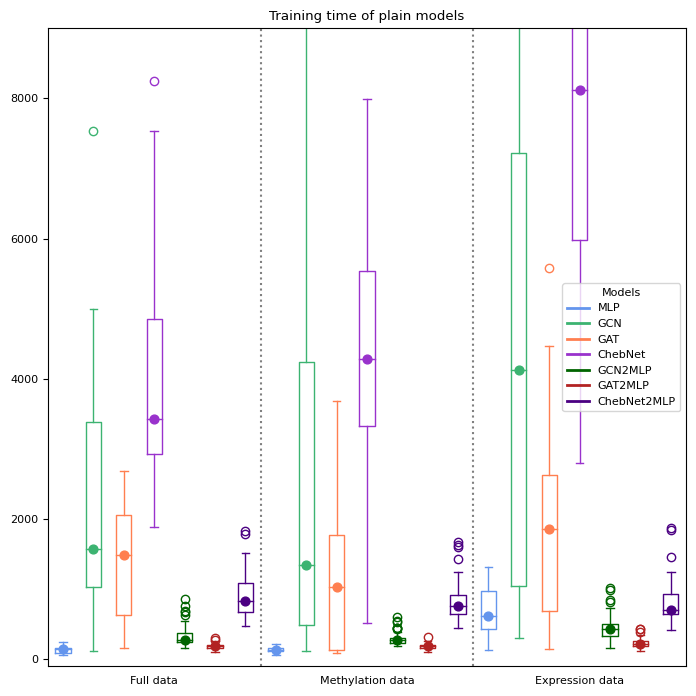

In [39]:
#RUNTIME VERSION 2 (ordered like Experiment 1 plot)

# RUNTIME
mpl.rcParams.update({'font.size': 8})

colors = ['cornflowerblue', 'mediumseagreen', 'coral', 'darkorchid', 'darkgreen', 'firebrick', 'indigo' ]
symbols = ['o', '^', 's'] 

data = [    MLP_outer_ext['time_total_s'],
            GCN_outer_ext['time_total_s'],
            GAT_outer_ext['time_total_s'],
            ChebNet_outer_ext['time_total_s'],
            GCN2MLP_outer_ext['time_total_s'],
            GAT2MLP_outer_ext['time_total_s'],
            ChebNet2MLP_outer_ext['time_total_s'],
            mMLP_outer_ext['time_total_s'],
            mGCN_outer_ext['time_total_s'],
            mGAT_outer_ext['time_total_s'],
            mChebNet_outer_ext['time_total_s'],
            mGCN2MLP_outer_ext['time_total_s'],
            mGAT2MLP_outer_ext['time_total_s'],
            mChebNet2MLP_outer_ext['time_total_s'],
            xMLP_outer_ext['time_total_s'],
            xGCN_outer_ext['time_total_s'],
            xGAT_outer_ext['time_total_s'],
            xChebNet_outer_ext['time_total_s'],
            xGCN2MLP_outer_ext['time_total_s'],
            xGAT2MLP_outer_ext['time_total_s'],
            xChebNet2MLP_outer_ext['time_total_s']
            ]

group_colors = [colors[0],colors[0],colors[0]]

group_symbols = [symbols[0],symbols[0],symbols[0],
                 symbols[0],symbols[0],symbols[0],
                 symbols[0],symbols[0],symbols[0],
                 symbols[0],symbols[0],symbols[0],
                 symbols[0],symbols[0],symbols[0],
                 symbols[0],symbols[0],symbols[0],
                 symbols[0],symbols[0],symbols[0],
                 symbols[0],
                 symbols[0],symbols[0],symbols[0],symbols[0],symbols[0],symbols[0],
                 symbols[0],symbols[0],symbols[0],symbols[0],symbols[0],symbols[0],
                 symbols[0],symbols[0],symbols[0],symbols[0],symbols[0],symbols[0],
                 symbols[0],symbols[0],symbols[0],symbols[0],symbols[0],symbols[0]]

fig, ax = plt.subplots(figsize=(7,7)) # for large version: (14,12)
bp = ax.boxplot(data, showcaps=True)

for i in range(len(bp['boxes'])):
    group_color = colors[(i//1)%7]
    symbol = group_symbols[i]

    bp['boxes'][i].set(color=group_color, linewidth=1)
    bp['caps'][2 * i].set(color=group_color, linewidth=1)    
    bp['caps'][2 * i + 1].set(color=group_color, linewidth=1)  
    bp['whiskers'][2 * i].set(color=group_color, linewidth=1)     
    bp['whiskers'][2 * i + 1].set(color=group_color,  linewidth=1) 

    median = np.median(data[i])
    ax.scatter(i + 1, median, color=group_color,  marker=symbol, s=40, zorder=3)
    bp['medians'][i].set(color=group_color, linewidth=1)
    bp['fliers'][i].set(markeredgecolor=group_color)


#plt.axvline(x=1.5, color='grey', linestyle=':')
plt.axvline(x=7.5, color='grey', linestyle=':')
plt.axvline(x=14.5, color='grey', linestyle=':')


groups_colors = ['MLP', 'GCN', 'GAT', 'ChebNet', 'GCN2MLP', 'GAT2MLP', 'ChebNet2MLP']
groups_shapes = ['Plain']

legend_handles = [
                    Line2D([0], [0], color=color, lw=2, label=name)
                    for color, name in zip(colors, groups_colors)
                ]


ax.legend(handles=legend_handles, title='Models')
ax.set_xticks([4, 11, 18],['Full data', 'Methylation data', 'Expression data'] )
ax.xaxis.set_ticks_position('none') 
ax.set_title('Training time of plain models')

ax.set_ylim(-100, 9000) #better overview

plt.tight_layout()

plt.savefig(path+'/final_box_time_2.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/final_box_time_2.pdf', bbox_inches='tight')

plt.show()

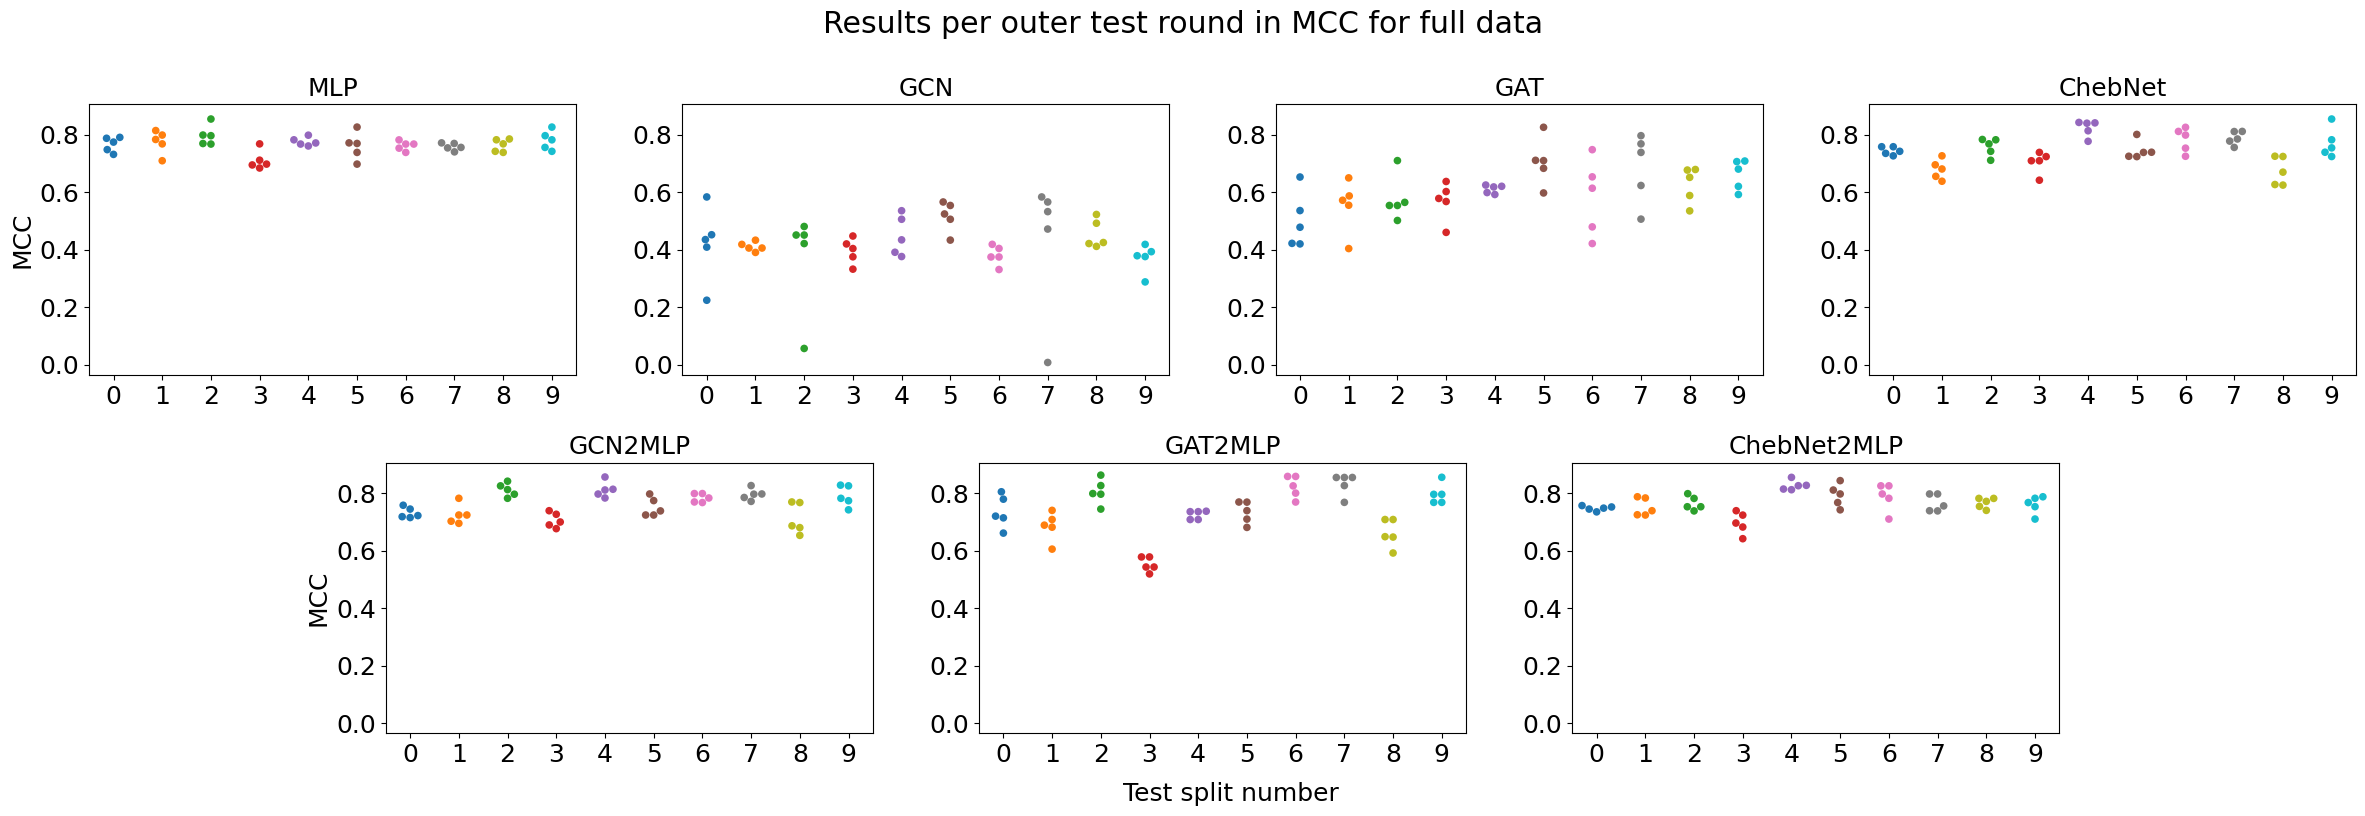

In [43]:
#SWARMPLOTS
#FULL DATA PARTIALLY (only plain)
import matplotlib.gridspec as gridspec
mpl.rcParams.update({'font.size': 18})

fig = plt.figure(figsize=(24, 8))

gs = gridspec.GridSpec(2, 8, height_ratios=[1, 1])#.8]) 
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4], sharey=ax1)
ax3 = fig.add_subplot(gs[0, 4:6], sharey=ax1)
ax3_2 = fig.add_subplot(gs[0, 6:8], sharey=ax1)
ax4 = fig.add_subplot(gs[1, 1:3], sharey=ax1)
ax5 = fig.add_subplot(gs[1, 3:5], sharey=ax1)
ax5_2 = fig.add_subplot(gs[1, 5:7], sharey=ax1)

MLP = pd.DataFrame()
GCN = pd.DataFrame()
GAT = pd.DataFrame()
ChebNet = pd.DataFrame()
GCN2MLP = pd.DataFrame()
GAT2MLP = pd.DataFrame()
ChebNet2MLP = pd.DataFrame()


for i in range(10):
   MLP[str(i)] = MLP_outer_ext['test_mcc'][MLP_outer_ext['config/train_loop_config/dataset_test_round']==i].reset_index(drop=True)
   GCN[str(i)] = GCN_outer_ext['test_mcc'][GCN_outer_ext['config/train_loop_config/dataset_test_round']==i].reset_index(drop=True)
   GAT[str(i)] = GAT_outer_ext['test_mcc'][GAT_outer_ext['config/train_loop_config/dataset_test_round']==i].reset_index(drop=True)
   ChebNet[str(i)] = ChebNet_outer_ext['test_mcc'][ChebNet_outer_ext['config/train_loop_config/dataset_test_round']==i].reset_index(drop=True)
   GCN2MLP[str(i)] = GCN2MLP_outer_ext['test_mcc'][GCN2MLP_outer_ext['config/train_loop_config/dataset_test_round']==i].reset_index(drop=True)
   GAT2MLP[str(i)] = GAT2MLP_outer_ext['test_mcc'][GAT2MLP_outer_ext['config/train_loop_config/dataset_test_round']==i].reset_index(drop=True)
   ChebNet2MLP[str(i)] = ChebNet2MLP_outer_ext['test_mcc'][ChebNet2MLP_outer_ext['config/train_loop_config/dataset_test_round']==i].reset_index(drop=True)

sns.swarmplot(MLP, ax=ax1, size=5.5)
sns.swarmplot(GCN, ax=ax2, size=5.5)
sns.swarmplot(GAT, ax=ax3, size=5.5)
sns.swarmplot(ChebNet, ax=ax3_2, size=5.5)
sns.swarmplot(GCN2MLP, ax=ax4, size=5.5)
sns.swarmplot(GAT2MLP, ax=ax5, size=5.5)
sns.swarmplot(ChebNet2MLP, ax=ax5_2, size=5.5)

ax1.set_ylabel('MCC')
ax1.set_title('MLP', fontsize=18)
ax2.set_title('GCN', fontsize=18)
ax3.set_title('GAT', fontsize=18)
ax3_2.set_title('ChebNet', fontsize=18)
ax4.set_ylabel('MCC')
ax4.set_title('GCN2MLP', fontsize=18)
ax5.set_title('GAT2MLP', fontsize=18)
ax5_2.set_title('ChebNet2MLP', fontsize=18)
#ax[2].set_xlabel('Test run number')
fig.text(0.52, 0, 'Test split number',ha='center', va='center', fontsize=18)


fig.suptitle('Results per outer test round in MCC for full data')
plt.tight_layout()

plt.savefig(path+'/final_swarm_full_part.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/final_swarm_full_part.pdf', bbox_inches='tight')

plt.show()

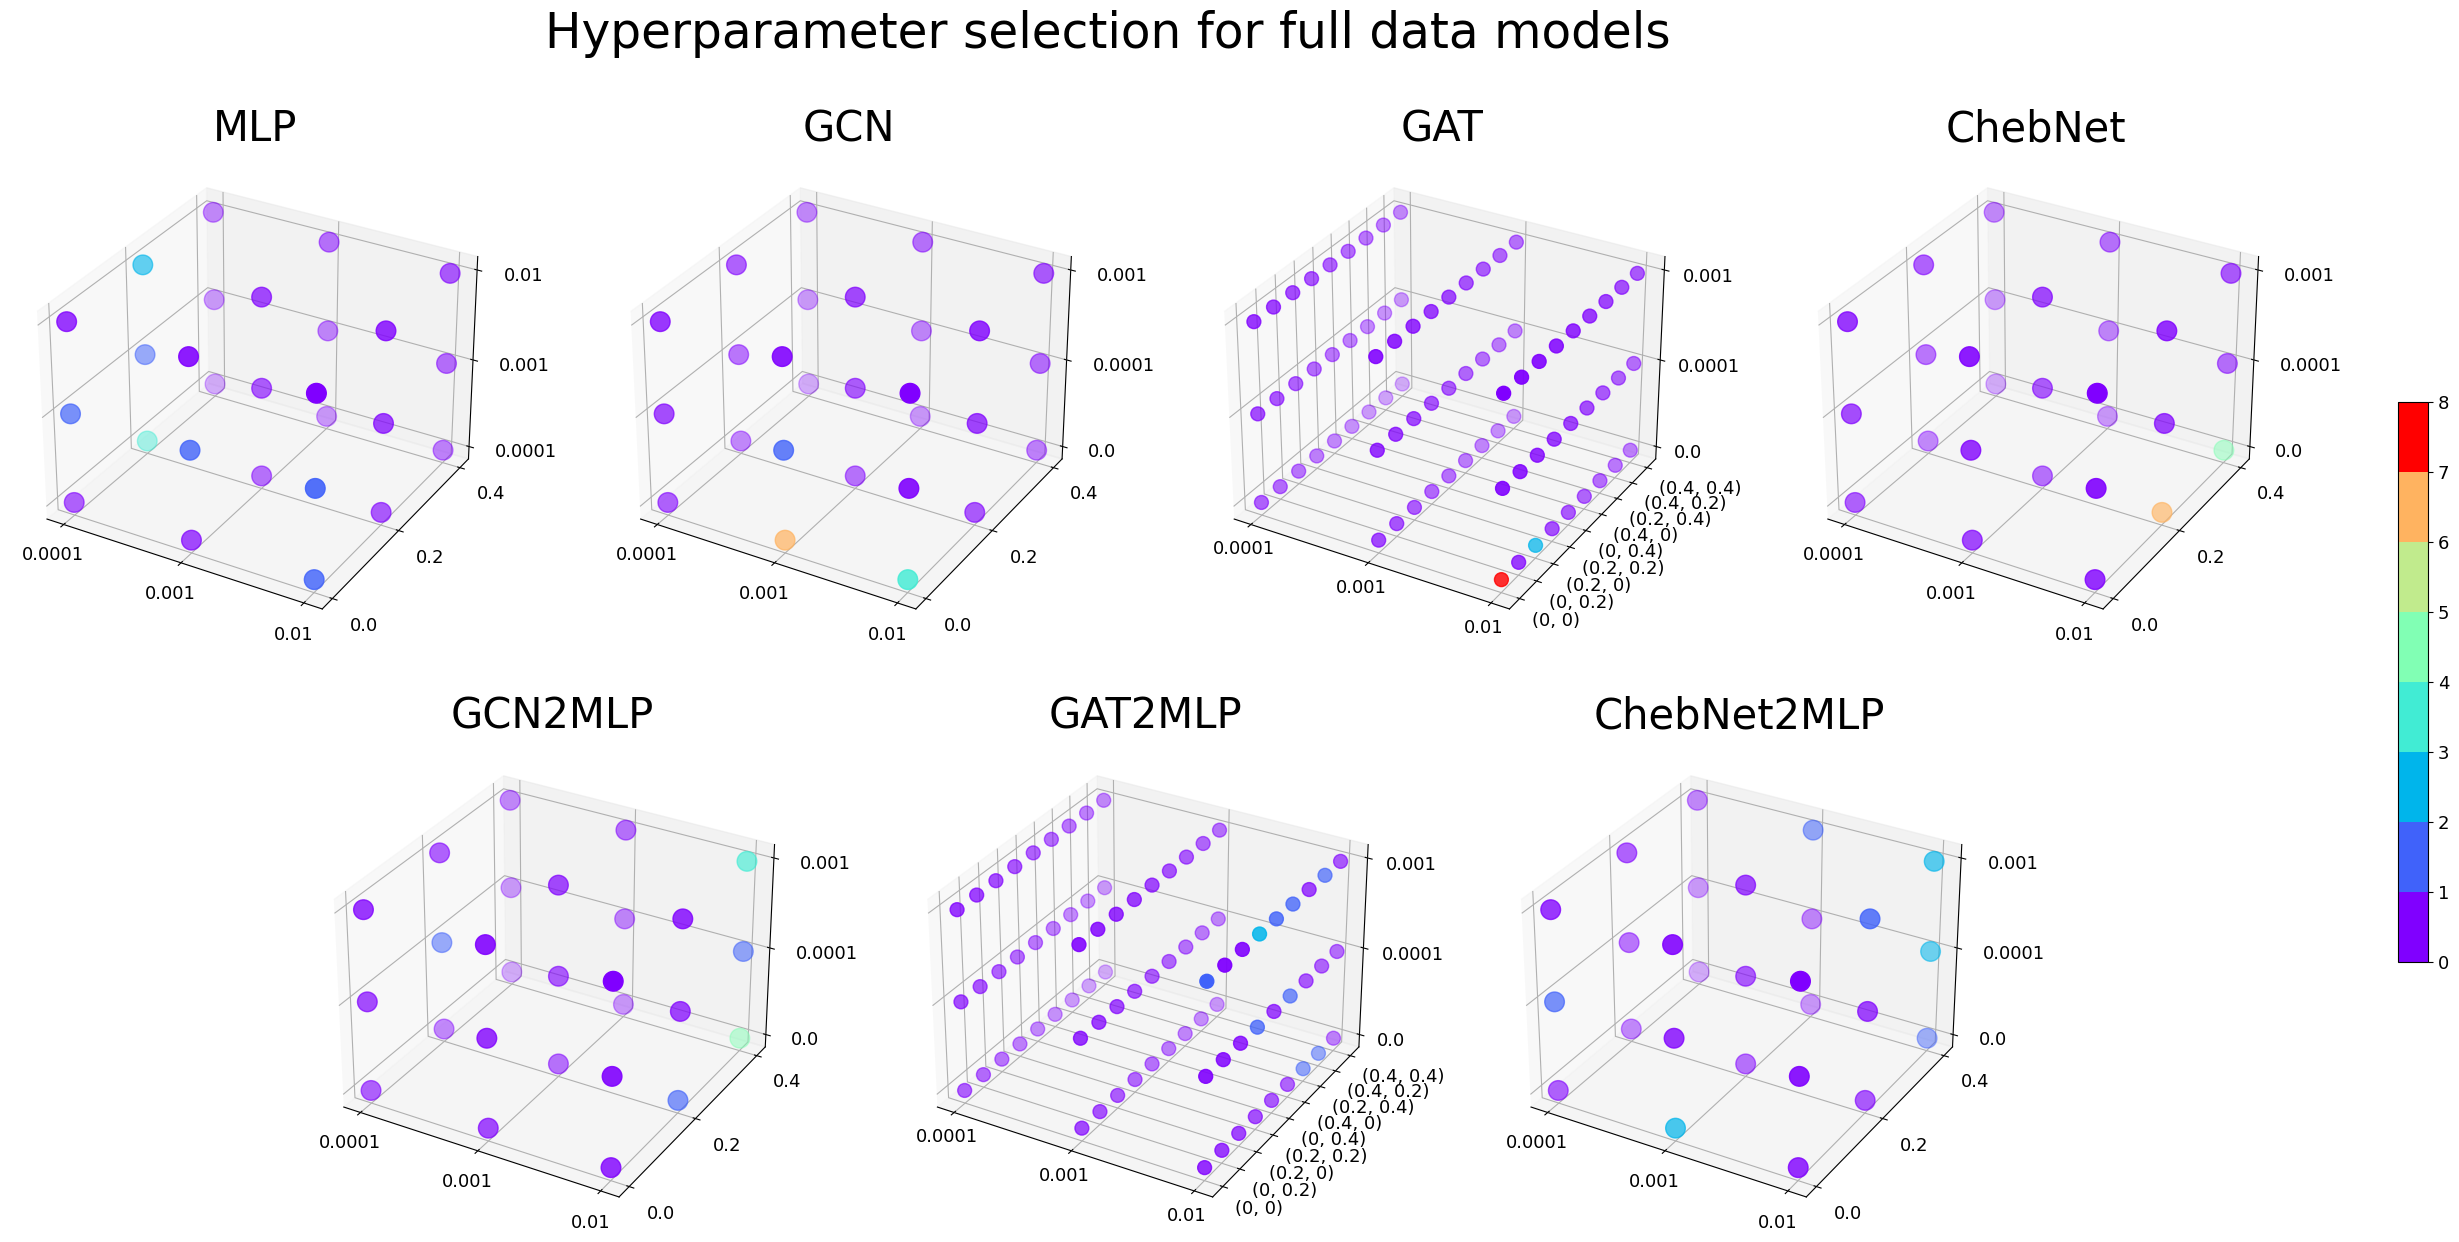

In [ ]:
#SHORT - FULL DATA
import matplotlib.gridspec as gridspec
mpl.rcParams.update({'font.size': 13})

translate_lr = {0.00001:0, 0.0001:1, 0.001:2, 0.01:3, 0.1:4}

fig = plt.figure(figsize=(30, 14))
fig.suptitle('Hyperparameter selection for full data models', size=35)

gs = gridspec.GridSpec(2, 8, height_ratios=[1, 1])#.8]) 
ax1 = fig.add_subplot(gs[0, 0:2], projection='3d')
ax2 = fig.add_subplot(gs[0, 2:4], projection='3d')
ax3 = fig.add_subplot(gs[0, 4:6], projection='3d')
ax3_2 = fig.add_subplot(gs[0, 6:8], projection='3d')
ax4 = fig.add_subplot(gs[1, 1:3], projection='3d')
ax5 = fig.add_subplot(gs[1, 3:5], projection='3d')
ax5_2 = fig.add_subplot(gs[1, 5:7], projection='3d')

#ax = np.array([fig.add_subplot(1,7,i, projection='3d') for i in range(1,8,1)]).reshape(7,1)

max_val = 9
colors = plt.cm.rainbow(np.linspace(0, 1, max_val))
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(np.arange(max_val), cmap.N)
colorbar = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

plot_grid('MLP', MLP_inner_ext, MLP_outer_av, ax1, cmap, norm)
plot_grid('GCN', GCN_inner_ext, GCN_outer_av, ax2, cmap, norm)
plot_grid_gat('GAT', GAT_inner_ext, GAT_outer_av, ax3, cmap, norm)
plot_grid('ChebNet', ChebNet_inner_ext, ChebNet_outer_av, ax3_2, cmap, norm)
plot_grid('GCN2MLP', GCN2MLP_inner_ext, GCN2MLP_outer_av, ax4, cmap, norm)
plot_grid_gat('GAT2MLP', GAT2MLP_inner_ext, GAT2MLP_outer_av, ax5, cmap, norm)
plot_grid('ChebNet2MLP', ChebNet2MLP_inner_ext, ChebNet2MLP_outer_av, ax5_2, cmap, norm)

#fig.subplots_adjust(right=0.85)
#fig.subplots_adjust(bottom=-0.1)
fig.subplots_adjust()
cbar_ax = fig.add_axes([0.93, 0.3, 0.01, 0.4])
fig.colorbar(colorbar, cax=cbar_ax)

'''
plt.savefig(path+'/final_hyp_selection_full_short.png', bbox_inches='tight', dpi=400)
plt.savefig(path+'/final_hyp_selection_full_short.pdf', bbox_inches='tight')
'''
plt.show()